In [4]:
here::i_am("atac/archR/processing/save_atac_matrices.R")

#source(here::here("settings.R"))
#source(here::here("utils.R"))

#suppressPackageStartupMessages(library(ArchR))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [5]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code/atac/archR"

In [9]:
test = fread('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/original/1A_Eo_DEG_G9_day3/outs/atac_fragments.tsv.gz')

Warning message in fread("/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/original/1A_Eo_DEG_G9_day3/outs/atac_fragments.tsv.gz"):
“Detected 1 column names but the data has 5 columns (i.e. invalid file). Added 4 extra default column names at the end.”


In [14]:
test = test[, size:=V3-V2]

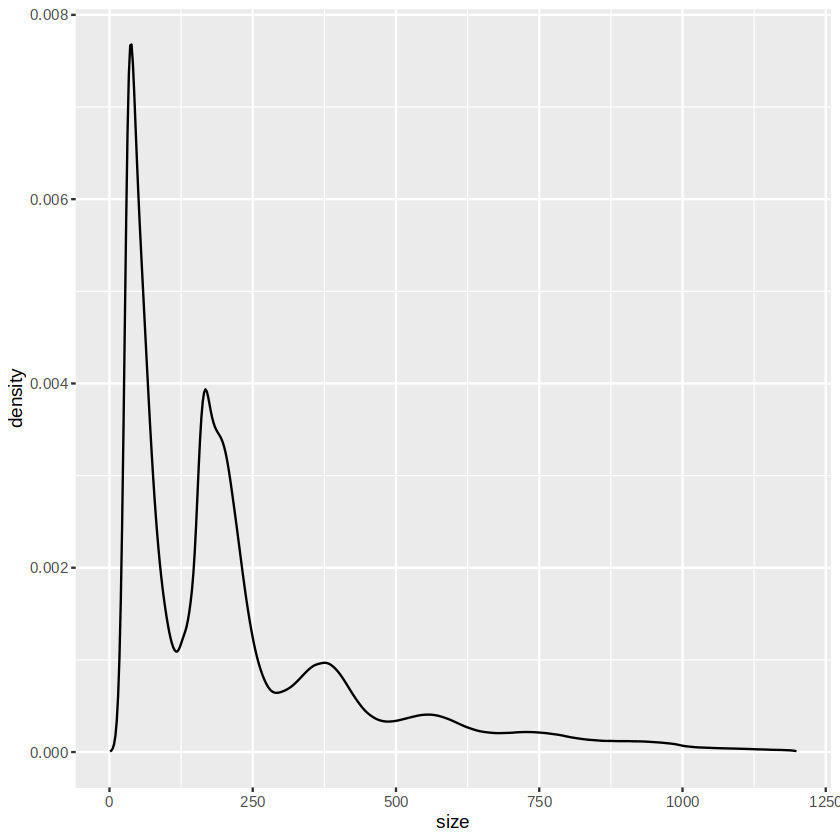

In [17]:
ggplot(head(test[size<1200], 1e7), aes(size)) + geom_density()

In [2]:
args <- list()

args$archr_directory <- file.path(io$basedir,"processed/atac/archR")

ArchRProject <- loadArchRProject(args$archr_directory)


Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [3]:
test = as.data.table(ArchRProject@cellColData)

In [7]:
colnames(test)

[1] "Sample"                    "TSSEnrichment"            
 [3] "ReadsInTSS"                "ReadsInPromoter"          
 [5] "ReadsInBlacklist"          "PromoterRatio"            
 [7] "PassQC"                    "NucleosomeRatio"          
 [9] "nMultiFrags"               "nMonoFrags"               
[11] "nFrags"                    "nDiFrags"                 
[13] "BlacklistRatio"            "barcode"                  
[15] "sample"                    "nFeature_RNA"             
[17] "nCount_RNA"                "mitochondrial_percent_RNA"
[19] "ribosomal_percent_RNA"     "alias"                    
[21] "day"                       "genotype"                 
[23] "pass_rnaQC"                "doublet_score"            
[25] "doublet_call"              "celltype"                 
[27] "celltype.score"            "closest.cell"             
[29] "day_celltype"              "celltype_genotype"        
[31] "TSSEnrichment_atac"        "ReadsInTSS_atac"          
[33] "PromoterRatio_atac"        "NucleosomeRatio_atac"     
[35] "nFrags_atac"               "BlacklistRatio_atac"      
[37] "ReadsInPeaks"              "FRIP"

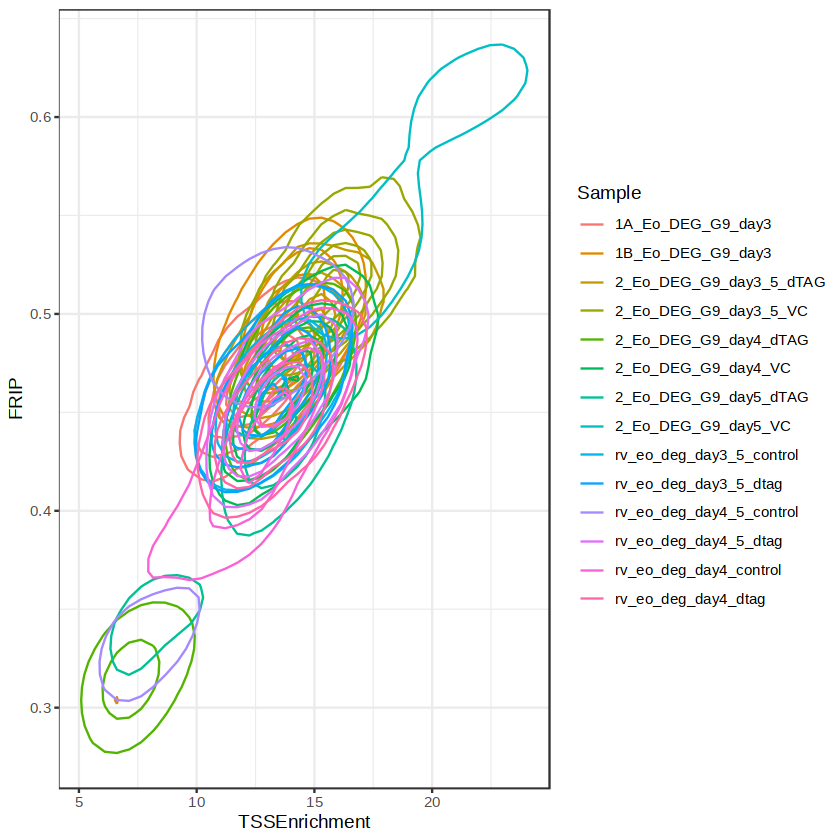

In [13]:
ggplot(test[PassQC==TRUE], aes(TSSEnrichment, FRIP, col=Sample)) + geom_density_2d() + theme_bw()

In [4]:
# START TEST ##b
args <- list()
args$archr_directory <- file.path(io$basedir,"processed/atac/archR")
args$metadata <- file.path(io$basedir,"results/atac/archR/qc/sample_metadata_after_qc.txt.gz")
args$matrix <- "GeneScoreMatrix_TSS"
args$outfile <- file.path(io$basedir,sprintf("processed/atac/archR/Matrices/%s_summarized_experiment.rds",args$matrix))
# END TEST ##

In [5]:
args$group_by = 'celltype_genotype'
args$min_cells = 100
args$tile_size = 1000
args$threads = 1

In [6]:
########################
## Load cell metadata ##
########################

sample_metadata <- fread(args$metadata) %>%
  .[pass_atacQC==TRUE & sample%in%opts$samples]

# temporary
# sample_metadata[,day:=stringr::str_replace_all(sample,opts$sample2day)] %>%
#   .[,genotype:=stringr::str_replace_all(sample,opts$sample2genotype)] %>%
#   .[,day_genotype:=paste(day,genotype,sep="_")] %>%
#   .[,celltype_genotype:=paste(celltype.mapped_mnn,genotype,sep="_")]

# Filter groups by minimum number of cells
stopifnot(args$group_by%in%colnames(sample_metadata))
sample_metadata <- sample_metadata[!is.na(sample_metadata[[args$group_by]])]
sample_metadata <- sample_metadata[!grepl("NA",sample_metadata[[args$group_by]])]
sample_metadata <- sample_metadata[,N:=.N,by=c(args$group_by)] %>% .[N>=args$min_cells] %>% .[,N:=NULL]

table(sample_metadata[[args$group_by]])

########################
## Load ArchR project ##
########################

# source(here::here("atac/archR/load_archR_project.R"))

setwd(args$archr_directory)

addArchRGenome("mm10")
addArchRThreads(threads = args$threads)


ERROR: Error: args$group_by %in% colnames(sample_metadata) is not TRUE


In [ ]:
nrow(sample_metadata)

In [ ]:
ArchRProject <- loadArchRProject(args$archr_directory)
# Subset
ArchRProject.filt <- ArchRProject[sample_metadata$cell]

In [40]:
ArchRProject
ArchRProject.filt


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR 
samples(2): 2_Eo_DEG_G9_day5_dTAG 2_Eo_DEG_G9_day5_VC
sampleColData names(1): ArrowFiles
cellColData names(36): Sample TSSEnrichment ... nFrags_atac
  BlacklistRatio_atac
numberOfCells(1): 4376
medianTSS(1): 14.2185
medianFrags(1): 6850.5


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR 
samples(2): 2_Eo_DEG_G9_day5_dTAG 2_Eo_DEG_G9_day5_VC
sampleColData names(1): ArrowFiles
cellColData names(36): Sample TSSEnrichment ... nFrags_atac
  BlacklistRatio_atac
numberOfCells(1): 1356
medianTSS(1): 14.3535
medianFrags(1): 54250.5

In [41]:


# Unnecesary, but just to make sure projectMetadata is updated
tmp <- file.path(args$archr_directory,"projectMetadata.rds")
if (file.exists(tmp)) ArchRProject.filt@projectMetadata <- readRDS(tmp)

###########################
## Update ArchR metadata ##
###########################

sample_metadata.to.archr <- sample_metadata %>% 
  .[cell%in%rownames(ArchRProject.filt)] %>% setkey(cell) %>% .[rownames(ArchRProject.filt)] %>%
  as.data.frame() %>% tibble::column_to_rownames("cell")

stopifnot(all(rownames(sample_metadata.to.archr) == rownames(getCellColData(ArchRProject.filt))))
ArchRProject.filt <- addCellColData(
  ArchRProject.filt,
  data = sample_metadata.to.archr[[args$group_by]],
  name = args$group_by,
  cells = rownames(sample_metadata.to.archr),
  force = TRUE
)

# print cell numbers
# table(getCellColData(ArchRProject,"Sample")[[1]])
table(getCellColData(ArchRProject.filt,args$group_by)[[1]])


Overriding previous entry for celltype_genotype




                     Allantois-eomes_ko                            Allantois-wt 
                                    943                                     278 
Haematoendothelial_progenitors-eomes_ko 
                                    135 

In [42]:
ArchRProject.filt <- addGroupCoverages(ArchRProject.filt, 
  groupBy = args$group_by,
  useLabels = FALSE,  # do not use sample information
  minCells = args$min_cells,
  maxCells = 5000,
  force = TRUE
)

ArchR logging to : ArchRLogs/ArchR-addGroupCoverages-8692190c14d3-Date-2022-05-27_Time-17-12-12.log
If there is an issue, please report to github with logFile!

Allantois-eomes_ko (1 of 3) : CellGroups N = 2

Allantois-wt (2 of 3) : CellGroups N = 2

Haematoendothelial_progenitors-eomes_ko (3 of 3) : CellGroups N = 2

2022-05-27 17:12:14 : Creating Coverage Files!, 0.033 mins elapsed.

2022-05-27 17:12:14 : Batch Execution w/ safelapply!, 0.033 mins elapsed.

2022-05-27 17:12:14 : Group Allantois-eomes_ko._.Rep1 (1 of 6) : Creating Group Coverage File : Allantois.eomes_ko._.Rep1.insertions.coverage.h5, 0.033 mins elapsed.

Number of Cells = 100

Coverage File Exists!

Added Coverage Group

Added Metadata Group

Added ArrowCoverage Class

Added Coverage/Info

Added Coverage/Info/CellNames

2022-05-27 17:12:42 : Group Allantois-eomes_ko._.Rep2 (2 of 6) : Creating Group Coverage File : Allantois.eomes_ko._.Rep2.insertions.coverage.h5, 0.499 mins elapsed.

Number of Cells = 100

Coverage F

In [43]:
projectmeta = ArchRProject.filt@projectMetadata

In [44]:
ArchRProject <- loadArchRProject(args$archr_directory)
# Subset
ArchRProject.filt <- ArchRProject[sample_metadata$cell]

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [47]:
ArchRProject.filt@projectMetadata = projectmeta

In [49]:
saveRDS(ArchRProject.filt@projectMetadata, file.path(args$archr_directory,"projectMetadata.rds"))


In [51]:
readRDS(file.path(args$archr_directory,"projectMetadata.rds"))

List of length 2
names(2): outputDirectory GroupCoverages

In [48]:

##################
## Peak calling ##
##################
args$pathToMacs2 = findMacs2()
args$pvalue_cutoff = 1e-3
args$extend_summits = 300

ArchRProject.filt <- addReproduciblePeakSet(
  ArchRProj = ArchRProject.filt, 
  groupBy = args$group_by, 
  peakMethod = "Macs2",
  excludeChr = c("chrM", "chrY"),
  pathToMacs2 = args$pathToMacs2,
  cutOff = args$pvalue_cutoff,
  extendSummits = args$extend_summits,
  plot = FALSE,
  force = TRUE
)

################
## Save peaks ##
################

Searching For MACS2..

Found with $path!

ArchR logging to : ArchRLogs/ArchR-addReproduciblePeakSet-86927c6bdca9-Date-2022-05-27_Time-17-35-50.log
If there is an issue, please report to github with logFile!

Calling Peaks with Macs2

2022-05-27 17:35:50 : Peak Calling Parameters!, 0.006 mins elapsed.



                                                                          Group
Allantois-eomes_ko                                           Allantois-eomes_ko
Allantois-wt                                                       Allantois-wt
Haematoendothelial_progenitors-eomes_ko Haematoendothelial_progenitors-eomes_ko
                                        nCells nCellsUsed nReplicates nMin nMax
Allantois-eomes_ko                         943        196           2  100  100
Allantois-wt                               278        171           2  100  100
Haematoendothelial_progenitors-eomes_ko    135        133           2  100  100
                                        maxPeaks
Allantois-eomes_ko                         98000
Allantois-wt                               85500
Haematoendothelial_progenitors-eomes_ko    66500


2022-05-27 17:35:50 : Batching Peak Calls!, 0.006 mins elapsed.

2022-05-27 17:35:50 : Batch Execution w/ safelapply!, 0 mins elapsed.

2022-05-27 17:35:50 : Group 1 of 6, Calling Peaks with MACS2!, 0 mins elapsed.



In [23]:
sample_metadata_bu = sample_metadata
args$min_cells = 200

# Filter groups by minimum number of cells
stopifnot(args$group_by%in%colnames(sample_metadata))
sample_metadata <- sample_metadata[!is.na(sample_metadata[[args$group_by]])]
sample_metadata <- sample_metadata[!grepl("NA",sample_metadata[[args$group_by]])]
sample_metadata <- sample_metadata[,N:=.N,by=c(args$group_by)] %>% .[N>=args$min_cells] %>% .[,N:=NULL]
unique(sample_metadata[[args$group_by]])

[1] "Allantois-wt"       "Allantois-eomes_ko"

In [27]:
ArchRProject.filt <- ArchRProject[sample_metadata$cell]

In [28]:

##################
## Peak calling ##
##################
args$pathToMacs2 = findMacs2()
args$pvalue_cutoff = 1e-3
args$extend_summits = 300

ArchRProject.filt <- addReproduciblePeakSet(
  ArchRProj = ArchRProject.filt, 
  groupBy = args$group_by, 
  peakMethod = "Macs2",
  excludeChr = c("chrM", "chrY"),
  pathToMacs2 = args$pathToMacs2,
  cutOff = args$pvalue_cutoff,
  extendSummits = args$extend_summits,
  plot = FALSE,
  force = TRUE
)

################
## Save peaks ##
################

Searching For MACS2..

Found with $path!

ArchR logging to : ArchRLogs/ArchR-addReproduciblePeakSet-447416d484195-Date-2022-05-27_Time-14-15-43.log
If there is an issue, please report to github with logFile!

Calling Peaks with Macs2



ERROR: Error in data.frame(Group = names(coverageParams$cellGroups)[y], nCells = tableGroups[names(coverageParams$cellGroups)[y]], : row names contain missing values


Peaks have to be called on the same cell/group_by set as reproducible peaks are called on, otherwise it gives an error.

But we don't want to call peaks on group_by's with only <100 cells, so how do we exclude these?

Maybe run everything as normal, and then exclude these peaks in hindsight

In [34]:
args$min_cells = 100

In [35]:
########################
## Load cell metadata ##
########################

sample_metadata <- fread(args$metadata) %>%
  .[pass_atacQC==TRUE & sample%in%opts$samples]

# temporary
# sample_metadata[,day:=stringr::str_replace_all(sample,opts$sample2day)] %>%
#   .[,genotype:=stringr::str_replace_all(sample,opts$sample2genotype)] %>%
#   .[,day_genotype:=paste(day,genotype,sep="_")] %>%
#   .[,celltype_genotype:=paste(celltype.mapped_mnn,genotype,sep="_")]

# Filter groups by minimum number of cells
stopifnot(args$group_by%in%colnames(sample_metadata))
sample_metadata <- sample_metadata[!is.na(sample_metadata[[args$group_by]])]
sample_metadata <- sample_metadata[!grepl("NA",sample_metadata[[args$group_by]])]
sample_metadata <- sample_metadata[,N:=.N,by=c(args$group_by)] %>% .[N>=args$min_cells] %>% .[,N:=NULL]

table(sample_metadata[[args$group_by]])

########################
## Load ArchR project ##
########################

# source(here::here("atac/archR/load_archR_project.R"))

setwd(args$archr_directory)

addArchRGenome("mm10")
addArchRThreads(threads = args$threads)



                     Allantois-eomes_ko                            Allantois-wt 
                                    943                                     278 
Haematoendothelial_progenitors-eomes_ko 
                                    135 

Setting default genome to Mm10.

Setting default number of Parallel threads to 1.



In [ ]:
ArchRProject.filt <- ArchRProject[head(sample_metadata$cell, 100)]

In [ ]:
ArchRProject.filt

In [37]:
ArchRProject.filt <- addGroupCoverages(ArchRProject.filt, 
  groupBy = args$group_by,
  useLabels = FALSE,  # do not use sample information
  minCells = 200,
  maxCells = 1000,
  force = TRUE
)

ArchR logging to : ArchRLogs/ArchR-addGroupCoverages-4474178adb5bd-Date-2022-05-27_Time-14-18-16.log
If there is an issue, please report to github with logFile!

Allantois-eomes_ko (1 of 3) : CellGroups N = 2

Allantois-wt (2 of 3) : CellGroups N = 2

Haematoendothelial_progenitors-eomes_ko (3 of 3) : CellGroups N = 2

2022-05-27 14:18:17 : Creating Coverage Files!, 0.008 mins elapsed.

2022-05-27 14:18:17 : Batch Execution w/ safelapply!, 0.008 mins elapsed.

2022-05-27 14:18:17 : Group Allantois-eomes_ko._.Rep1 (1 of 6) : Creating Group Coverage File : Allantois.eomes_ko._.Rep1.insertions.coverage.h5, 0.009 mins elapsed.

Number of Cells = 200

Coverage File Exists!

Added Coverage Group

Added Metadata Group

Added ArrowCoverage Class

Added Coverage/Info

Added Coverage/Info/CellNames

2022-05-27 14:18:52 : Group Allantois-eomes_ko._.Rep2 (2 of 6) : Creating Group Coverage File : Allantois.eomes_ko._.Rep2.insertions.coverage.h5, 0.589 mins elapsed.

Number of Cells = 200

Coverage 

In [38]:

##################
## Peak calling ##
##################
args$pathToMacs2 = findMacs2()
args$pvalue_cutoff = 1e-3
args$extend_summits = 300

ArchRProject.filt <- addReproduciblePeakSet(
  ArchRProj = ArchRProject.filt, 
  groupBy = args$group_by, 
  peakMethod = "Macs2",
  excludeChr = c("chrM", "chrY"),
  pathToMacs2 = args$pathToMacs2,
  cutOff = args$pvalue_cutoff,
  extendSummits = args$extend_summits,
  plot = FALSE,
  force = TRUE
)

################
## Save peaks ##
################

Searching For MACS2..

Found with $path!

ArchR logging to : ArchRLogs/ArchR-addReproduciblePeakSet-447413bc7a65f-Date-2022-05-27_Time-14-26-15.log
If there is an issue, please report to github with logFile!

Calling Peaks with Macs2

2022-05-27 14:26:15 : Peak Calling Parameters!, 0.004 mins elapsed.



                                                                          Group
Allantois-eomes_ko                                           Allantois-eomes_ko
Allantois-wt                                                       Allantois-wt
Haematoendothelial_progenitors-eomes_ko Haematoendothelial_progenitors-eomes_ko
                                        nCells nCellsUsed nReplicates nMin nMax
Allantois-eomes_ko                         943        369           2  200  200
Allantois-wt                               278        265           2  200  200
Haematoendothelial_progenitors-eomes_ko    135        133           2  103  105
                                        maxPeaks
Allantois-eomes_ko                        150000
Allantois-wt                              132500
Haematoendothelial_progenitors-eomes_ko    66500


2022-05-27 14:26:15 : Batching Peak Calls!, 0.004 mins elapsed.

2022-05-27 14:26:15 : Batch Execution w/ safelapply!, 0 mins elapsed.

2022-05-27 14:26:15 : Group 1 of 6, Calling Peaks with MACS2!, 0 mins elapsed.

Running Macs2 with Params : macs2 callpeak -g 1.87e+09 --name Allantois.eomes_ko._.Rep1-1 --treatment /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/PeakCalls/InsertionBeds/Allantois.eomes_ko._.Rep1-1.insertions.bed --outdir /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/PeakCalls/InsertionBeds --format BED --call-summits --keep-dup all --nomodel --nolambda --shift -75 --extsize 150 -q 0.001

Warning message in data.table::fread(summitsFile, select = c(1, 2, 3, 5)):
“File '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/PeakCalls/InsertionBeds/Allantois.eomes_ko._.Rep1-1_summits.bed' has size 0. Returning a NULL data.table.”
2022-05-27 14:26:57 : Group 2 of 6, Ca

ERROR: Error in data.table::fread(summitsFile, select = c(1, 2, 3, 5)): File '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/PeakCalls/InsertionBeds/Allantois.eomes_ko._.Rep2-2_summits.bed' does not exist or is non-readable. getwd()=='/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR'


# Calculate QC to compare with Rabbit

In [ ]:
arch

In [11]:
args$metadata <- file.path(io$basedir,"results/atac/archR/qc/sample_metadata_after_qc.txt.gz")
sample_metadata = fread(args$metadata)[pass_rnaQC==TRUE & pass_atacQC==TRUE]

ArchRProject <- loadArchRProject(args$archr_directory)
# Subset
ArchRProject.filt <- ArchRProject[sample_metadata$cell]

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [13]:
sample_metadata = as.data.table(ArchRProject.filt@cellColData)

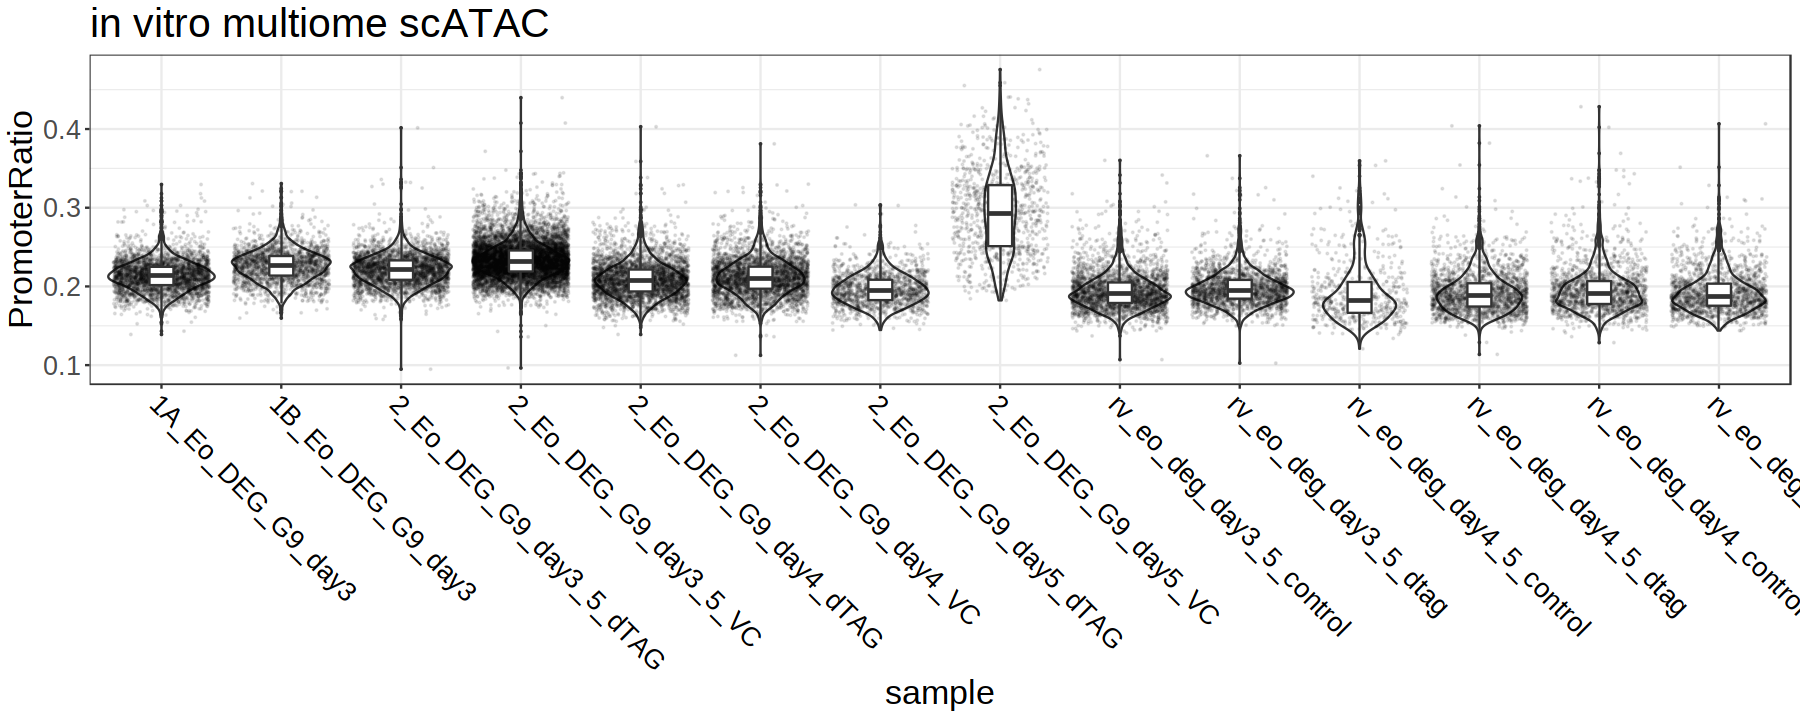

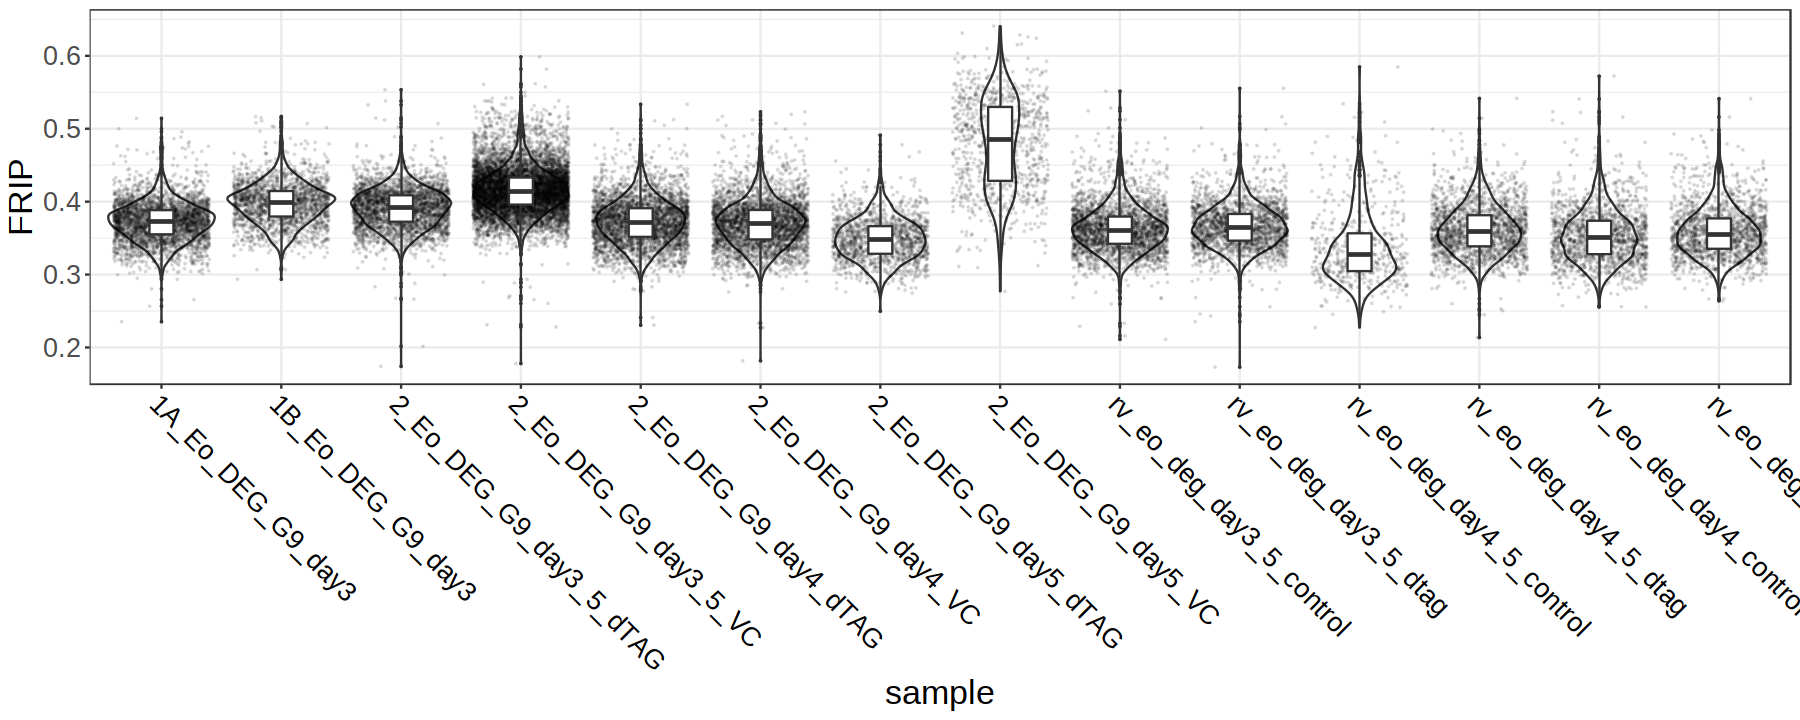

In [20]:
options(repr.plot.width=15, repr.plot.height=6)

ggplot(sample_metadata, aes(sample, PromoterRatio)) + 
    geom_violin() + 
    geom_point(position=position_jitter(width=0.4), size=0.1, alpha=0.1) + 
    geom_boxplot(width = 0.2, outlier.size=0) + 
    ggtitle('in vitro multiome scATAC') + 
    theme_bw() + 
    theme(text=element_text(size=20, color='black'), 
          axis.text.x=element_text(angle=-45, hjust=0, vjust=1, color='black'))

ggplot(sample_metadata, aes(sample, FRIP)) + 
    geom_violin() + 
    geom_point(position=position_jitter(width=0.4), size=0.1, alpha=0.1) + 
    geom_boxplot(width = 0.2, outlier.size=0) + 
    theme_bw() +
    theme(text=element_text(size=20, color='black'), 
          axis.text.x=element_text(angle=-45, hjust=0, vjust=1, color='black'))


In [ ]:
io$archR.peakMatrix.se

In [25]:
peak.mtx = readRDS('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds')

In [26]:
peak.mtx@assays@data$PeakMatrix

class: RangedSummarizedExperiment 
dim: 104278 38757 
metadata(0):
assays(1): PeakMatrix
rownames(104278): chr1:3003397-3003997 chr1:3191569-3192169 ...
  chrX:169880292-169880892 chrX:169883758-169884358
rowData names(1): idx
colnames(38757): 2_Eo_DEG_G9_day3_5_VC#ATAAGCCTCTTAGGGT-1
  2_Eo_DEG_G9_day3_5_VC#CGTTTGGAGGTCCGTA-1 ...
  2_Eo_DEG_G9_day5_VC#CTCCCTGAGGTGAAAT-1
  2_Eo_DEG_G9_day5_VC#CGCTCCATCATCCTGC-1
colData names(38): BlacklistRatio nDiFrags ... ReadsInPeaks FRIP

In [33]:
reads_in_peaks = data.table(cell=colnames(peak.mtx), ReadsInPeaks=colSums(peak.mtx@assays@data$PeakMatrix))

In [37]:
reads_in_peaks = reads_in_peaks[match(meta$cell, reads_in_peaks$cell)]

In [38]:
meta2 = cbind(meta, reads_in_peaks[,2])

In [40]:
meta2 = meta2[,FRIP:=ReadsInPeaks/nFrags_atac]

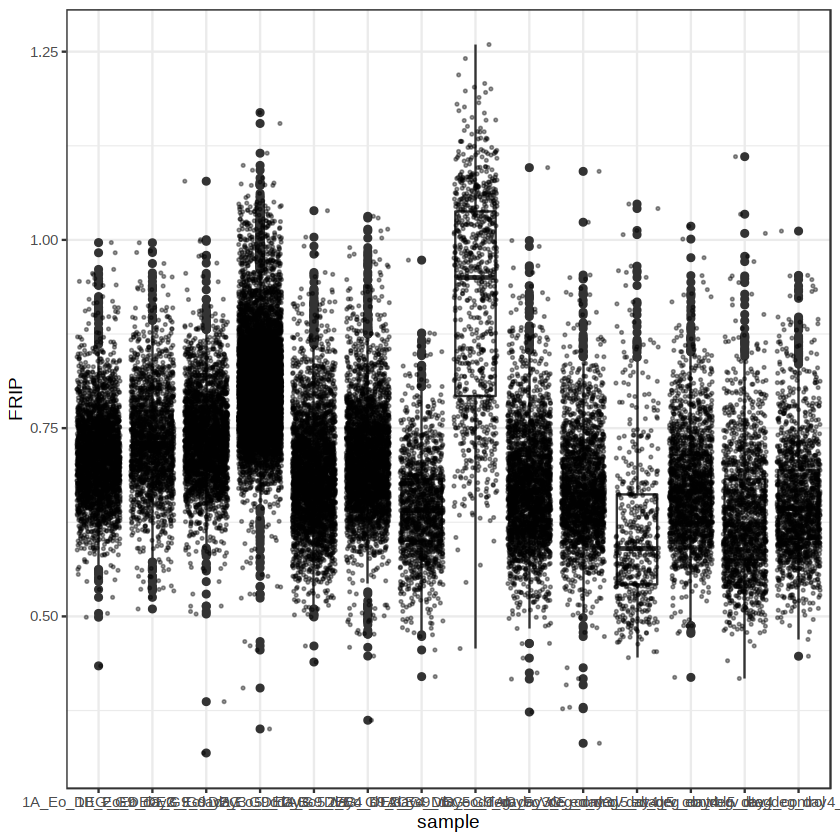

In [42]:
ggplot(meta2, aes(sample, FRIP)) + 
    geom_boxplot() + 
    geom_point(position=position_jitter(width=0.4), size=0.4, alpha=0.4) + 
    theme_bw()

In [22]:
tile.mtx =getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "TileMatrix")

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-2864e23defec4-Date-2022-11-18_Time-13-41-32.log
If there is an issue, please report to github with logFile!



ERROR: Error in .getMatFromArrow(ArrowFile = ArrowFile, featureDF = featureDF, : Sparse Matrix in Arrow is Binarized! Set binarize = TRUE to use matrix!


# Clustering TileMatrix trial

In [17]:
# START TEST ##b
args <- list()
args$archr_directory <- file.path(io$basedir,"processed/atac/archR")
args$metadata <- file.path(io$basedir,"results/atac/archR/qc/sample_metadata_after_qc.txt.gz")
# END TEST ##

In [18]:
meta = fread(args$metadat)[pass_atacQC==TRUE & doublet_call==FALSE]

In [19]:
nrow(meta)

[1] 33177

In [20]:
ArchRProject.filt = ArchRProject[meta$cell]

In [21]:
ArchRProject.filt


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR 
samples(14): rv_eo_deg_day3_5_control rv_eo_deg_day3_5_dtag ...
  2_Eo_DEG_G9_day5_dTAG 2_Eo_DEG_G9_day5_VC
sampleColData names(1): ArrowFiles
cellColData names(38): Sample TSSEnrichment ... ReadsInPeaks FRIP
numberOfCells(1): 33177
medianTSS(1): 14.119
medianFrags(1): 44481

In [34]:
addArchRThreads(16)

Setting default number of Parallel threads to 16.



In [35]:
getAvailableMatrices(ArchRProject.filt)

[1] "DeviationMatrix_CISBP"  "DeviationMatrix_JASPAR" "GeneScoreMatrix_TSS"   
[4] "GeneScoreMatrix_distal" "PeakMatrix"             "PeakMatrix_atlas"      
[7] "TileMatrix"

In [37]:
ArchRProject.filt <- addIterativeLSI(
    ArchRProj = ArchRProject.filt,
    useMatrix = "TileMatrix", 
    name = "IterativeLSI2", 
    iterations = 4, 
    clusterParams = list( #See Seurat::FindClusters
        resolution = c(0.1, 0.2, 0.4), 
        sampleCells = 10000, 
        n.start = 10
    ), 
    varFeatures = 20000, 
    dimsToUse = 1:30
)

ArchRProject.filt <- addUMAP(
    ArchRProj = ArchRProject.filt, 
    reducedDims = "IterativeLSI2", 
    name = "UMAP", 
    nNeighbors = 30, 
    minDist = 0.5, 
    metric = "cosine"
)

p1 <- plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "sample", embedding = "UMAP")

ArchRProject.filt <- addIterativeLSI(
    ArchRProj = ArchRProject.filt,
    useMatrix = "TileMatrix", 
    name = "IterativeLSI", 
    iterations = 2, 
    clusterParams = list( #See Seurat::FindClusters
        resolution = c(0.2), 
        sampleCells = 10000, 
        n.start = 10
    ), 
    varFeatures = 40000, 
    dimsToUse = 1:30
)

ArchRProject.filt <- addUMAP(
    ArchRProj = ArchRProject.filt, 
    reducedDims = "IterativeLSI", 
    name = "UMAP2", 
    nNeighbors = 30, 
    minDist = 0.5, 
    metric = "cosine"
)

p2 <- plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "sample", embedding = "UMAP2")

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-2e7e79aa73e2-Date-2023-01-23_Time-13-18-33.log
If there is an issue, please report to github with logFile!

2023-01-23 13:18:36 : Computing Total Across All Features, 0.012 mins elapsed.

2023-01-23 13:18:45 : Computing Top Features, 0.162 mins elapsed.

###########
2023-01-23 13:18:46 : Running LSI (1 of 4) on Top Features, 0.182 mins elapsed.
###########

2023-01-23 13:18:46 : Sampling Cells (N = 10008) for Estimated LSI, 0.184 mins elapsed.

2023-01-23 13:18:46 : Creating Sampled Partial Matrix, 0.184 mins elapsed.

2023-01-23 13:19:12 : Computing Estimated LSI (projectAll = FALSE), 0.605 mins elapsed.

Filtering 2 dims correlated > 0.75 to log10(depth + 1)

2023-01-23 13:20:57 : Identifying Clusters, 2.361 mins elapsed.

2023-01-23 13:21:10 : Identified 3 Clusters, 2.571 mins elapsed.

2023-01-23 13:21:10 : Saving LSI Iteration, 2.571 mins elapsed.

2023-01-23 13:21:24 : Creating Cluster Matrix on the total Grou

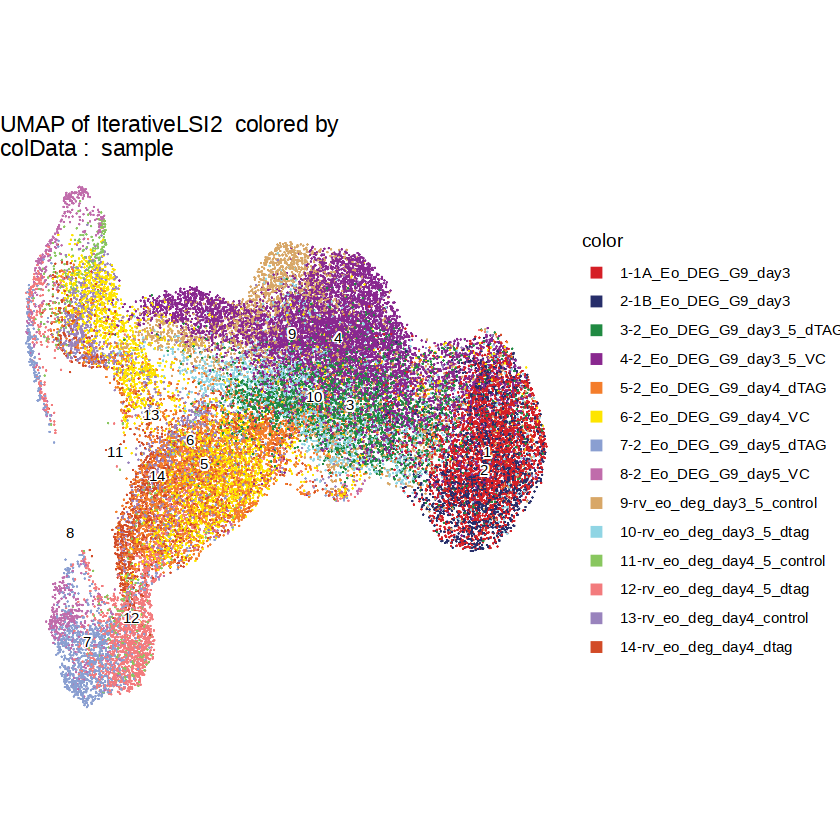

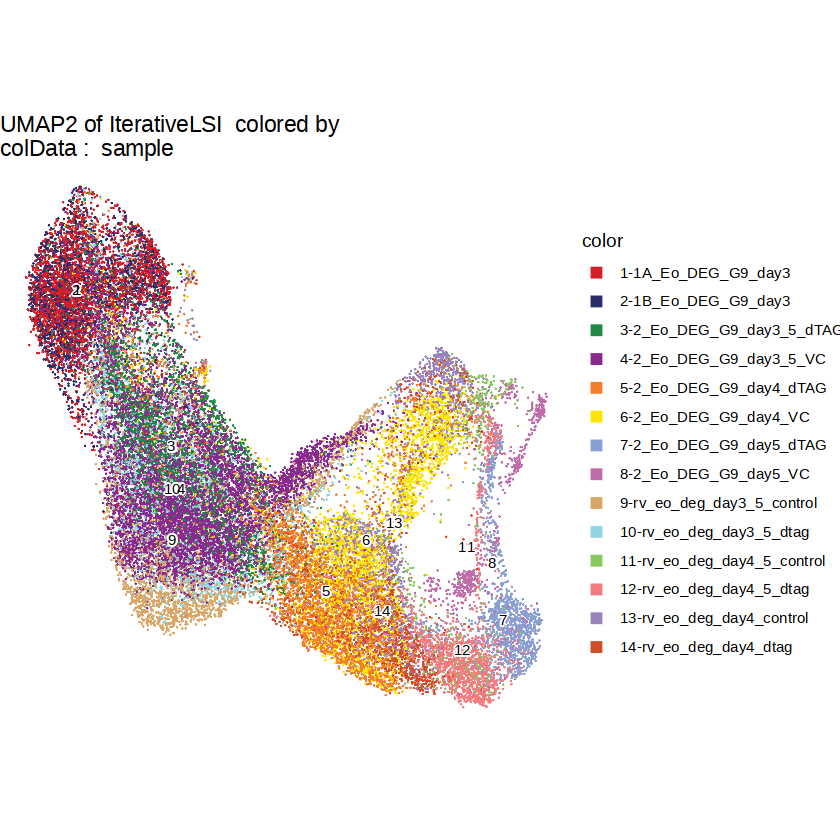

In [38]:
p1 + theme_void()

p2 + theme_void()

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-2e7e3c1e80f1-Date-2023-01-23_Time-13-33-24.log
If there is an issue, please report to github with logFile!

2023-01-23 13:33:27 : Computing Total Across All Features, 0.01 mins elapsed.

2023-01-23 13:33:31 : Computing Top Features, 0.071 mins elapsed.

###########
2023-01-23 13:33:32 : Running LSI (1 of 4) on Top Features, 0.089 mins elapsed.
###########

2023-01-23 13:33:32 : Sampling Cells (N = 10008) for Estimated LSI, 0.091 mins elapsed.

2023-01-23 13:33:32 : Creating Sampled Partial Matrix, 0.091 mins elapsed.

2023-01-23 13:33:53 : Computing Estimated LSI (projectAll = FALSE), 0.437 mins elapsed.

Filtering 1 dims correlated > 0.75 to log10(depth + 1)

2023-01-23 13:35:07 : Identifying Clusters, 1.676 mins elapsed.

2023-01-23 13:35:18 : Identified 8 Clusters, 1.856 mins elapsed.

2023-01-23 13:35:18 : Saving LSI Iteration, 1.857 mins elapsed.

2023-01-23 13:35:32 : Creating Cluster Matrix on the total Group

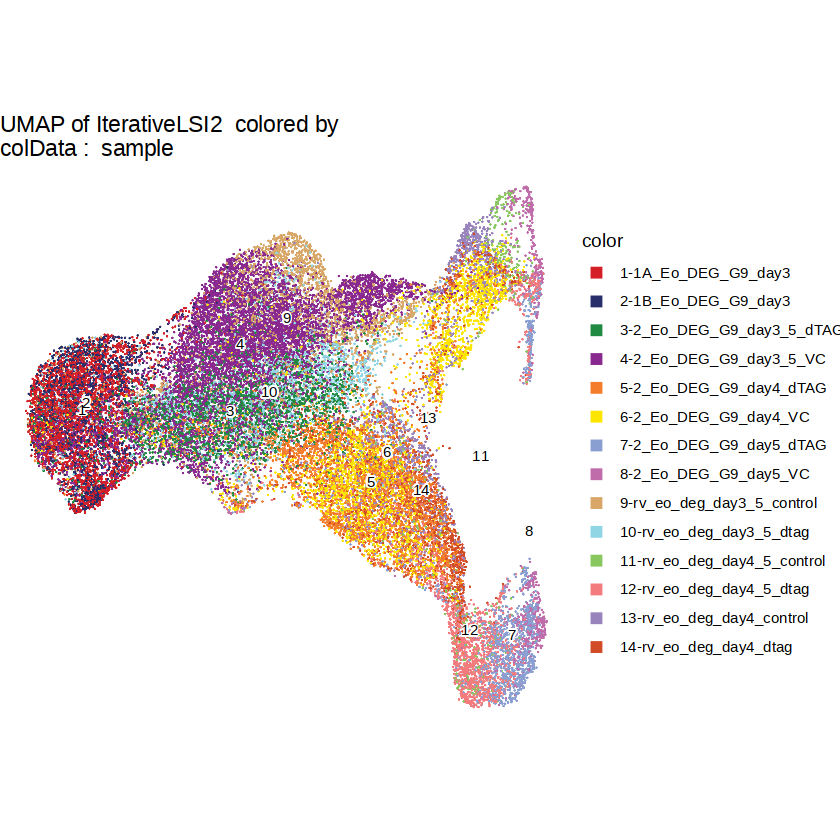

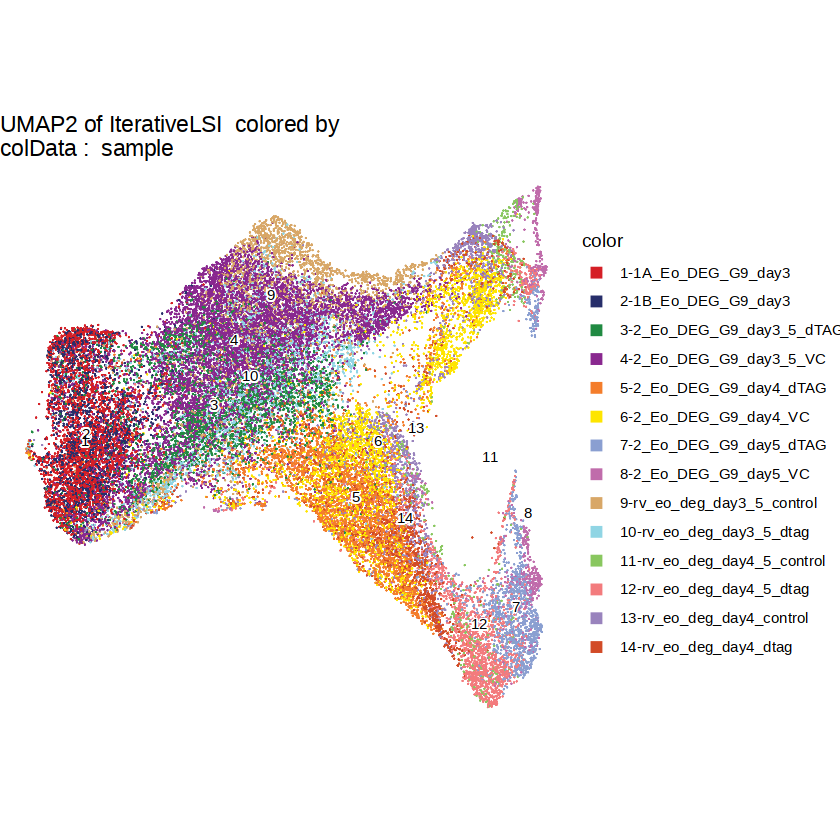

In [39]:
ArchRProject.filt <- addIterativeLSI(
    ArchRProj = ArchRProject.filt,
    useMatrix = "TileMatrix", 
    name = "IterativeLSI2", 
    iterations = 4, 
    clusterParams = list( #See Seurat::FindClusters
        resolution = c(0.4, 1, 2), 
        sampleCells = 10000, 
    maxClusters=NULL, 
        n.start = 10
    ), 
    varFeatures = 20000, 
    dimsToUse = 1:20, 
    force = TRUE
)

ArchRProject.filt <- addUMAP(
    ArchRProj = ArchRProject.filt, 
    reducedDims = "IterativeLSI2", 
    name = "UMAP", 
    nNeighbors = 25, 
    minDist = 0.3, 
    metric = "cosine",
    force = TRUE
)

p1 <- plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "sample", embedding = "UMAP")

ArchRProject.filt <- addIterativeLSI(
    ArchRProj = ArchRProject.filt,
    useMatrix = "TileMatrix", 
    name = "IterativeLSI", 
    iterations = 2, 
    clusterParams = list( #See Seurat::FindClusters
        resolution = c(2), 
        sampleCells = 10000, 
    maxClusters=NULL, 
        n.start = 10
    ), 
    varFeatures = 40000, 
    dimsToUse = 1:20,
    force = TRUE
)

ArchRProject.filt <- addUMAP(
    ArchRProj = ArchRProject.filt, 
    reducedDims = "IterativeLSI", 
    name = "UMAP2", 
    nNeighbors = 25, 
    minDist = 0.3, 
    metric = "cosine",
    force = TRUE
)

p2 <- plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "sample", embedding = "UMAP2")

p1 + theme_void()

p2 + theme_void()

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-2e7e75c775a4-Date-2023-01-23_Time-13-46-34.log
If there is an issue, please report to github with logFile!

2023-01-23 13:46:37 : Computing Total Across All Features, 0.009 mins elapsed.

2023-01-23 13:46:40 : Computing Top Features, 0.071 mins elapsed.

###########
2023-01-23 13:46:42 : Running LSI (1 of 4) on Top Features, 0.089 mins elapsed.
###########

2023-01-23 13:46:42 : Sampling Cells (N = 10008) for Estimated LSI, 0.09 mins elapsed.

2023-01-23 13:46:42 : Creating Sampled Partial Matrix, 0.09 mins elapsed.

2023-01-23 13:47:05 : Computing Estimated LSI (projectAll = FALSE), 0.475 mins elapsed.

Filtering 1 dims correlated > 0.75 to log10(depth + 1)

2023-01-23 13:47:49 : Identifying Clusters, 1.207 mins elapsed.

2023-01-23 13:48:00 : Identified 8 Clusters, 1.394 mins elapsed.

2023-01-23 13:48:00 : Saving LSI Iteration, 1.394 mins elapsed.

2023-01-23 13:48:14 : Creating Cluster Matrix on the total Group 

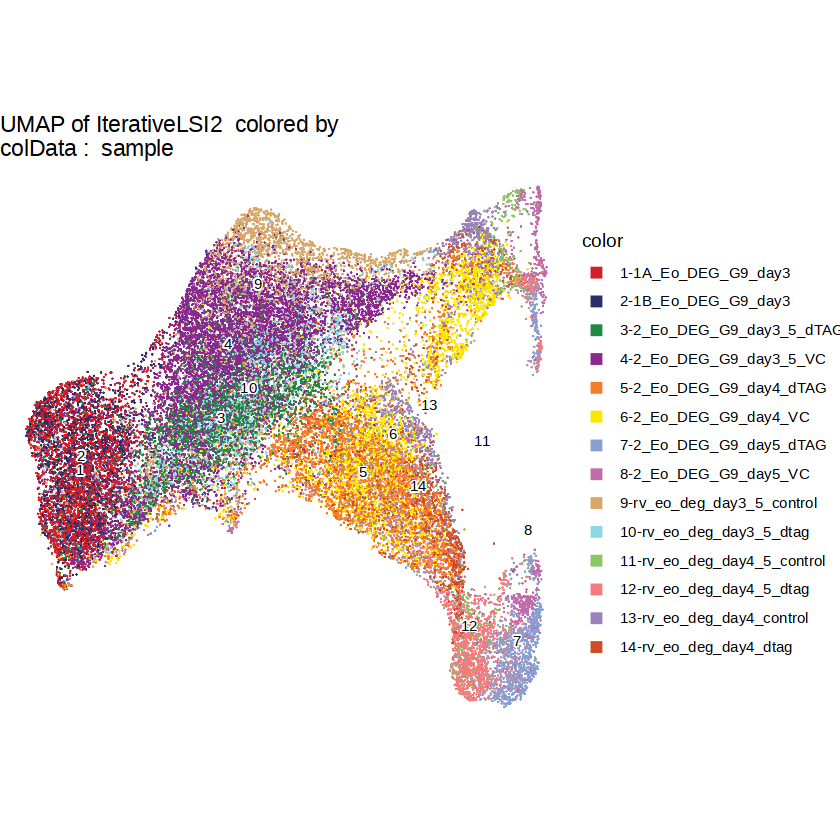

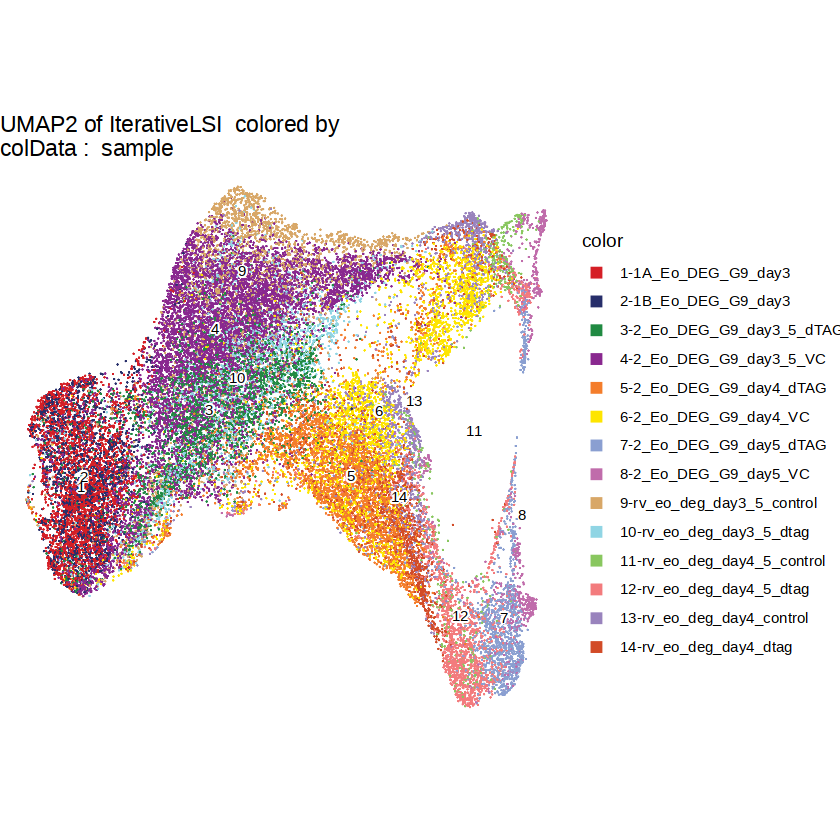

In [40]:
ArchRProject.filt <- addIterativeLSI(
    ArchRProj = ArchRProject.filt,
    useMatrix = "TileMatrix", 
    name = "IterativeLSI2", 
    iterations = 4, 
    clusterParams = list( #See Seurat::FindClusters
        resolution = c(0.4, 1, 2), 
        sampleCells = 10000, 
    maxClusters=NULL, 
        n.start = 10
    ), 
    varFeatures = 30000, 
    dimsToUse = 1:20, 
    force = TRUE
)

ArchRProject.filt <- addUMAP(
    ArchRProj = ArchRProject.filt, 
    reducedDims = "IterativeLSI2", 
    name = "UMAP", 
    nNeighbors = 25, 
    minDist = 0.3, 
    metric = "cosine",
    force = TRUE
)

p1 <- plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "sample", embedding = "UMAP")

ArchRProject.filt <- addIterativeLSI(
    ArchRProj = ArchRProject.filt,
    useMatrix = "TileMatrix", 
    name = "IterativeLSI", 
    iterations = 2, 
    clusterParams = list( #See Seurat::FindClusters
        resolution = c(2), 
        sampleCells = 10000, 
    maxClusters=NULL, 
        n.start = 10
    ), 
    varFeatures = 60000, 
    dimsToUse = 1:20,
    force = TRUE
)

ArchRProject.filt <- addUMAP(
    ArchRProj = ArchRProject.filt, 
    reducedDims = "IterativeLSI", 
    name = "UMAP2", 
    nNeighbors = 25, 
    minDist = 0.3, 
    metric = "cosine",
    force = TRUE
)

p2 <- plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "sample", embedding = "UMAP2")

p1 + theme_void()

p2 + theme_void()

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-2e7e1841474-Date-2023-01-23_Time-14-01-02.log
If there is an issue, please report to github with logFile!

2023-01-23 14:01:13 : Computing Total Across All Features, 0.138 mins elapsed.

2023-01-23 14:01:16 : Computing Top Features, 0.187 mins elapsed.

###########
2023-01-23 14:01:17 : Running LSI (1 of 4) on Top Features, 0.203 mins elapsed.
###########

2023-01-23 14:01:17 : Sampling Cells (N = 10008) for Estimated LSI, 0.205 mins elapsed.

2023-01-23 14:01:17 : Creating Sampled Partial Matrix, 0.205 mins elapsed.

2023-01-23 14:01:33 : Computing Estimated LSI (projectAll = FALSE), 0.467 mins elapsed.

Filtering 1 dims correlated > 0.75 to log10(depth + 1)

2023-01-23 14:02:03 : Identifying Clusters, 0.98 mins elapsed.

2023-01-23 14:02:15 : Identified 9 Clusters, 1.165 mins elapsed.

2023-01-23 14:02:15 : Saving LSI Iteration, 1.166 mins elapsed.

2023-01-23 14:02:30 : Creating Cluster Matrix on the total Group 

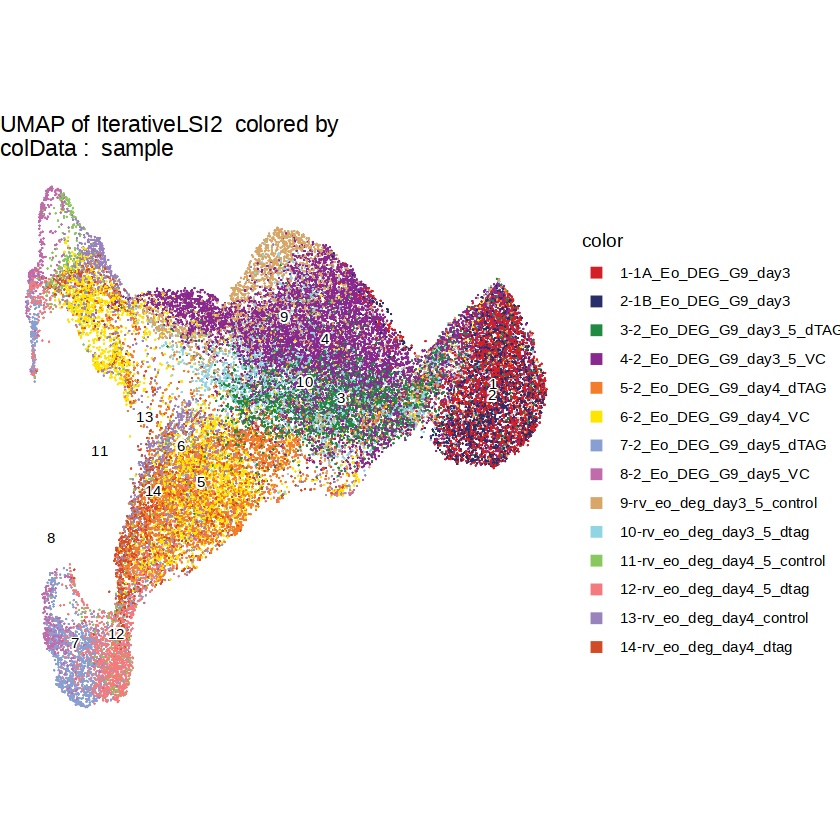

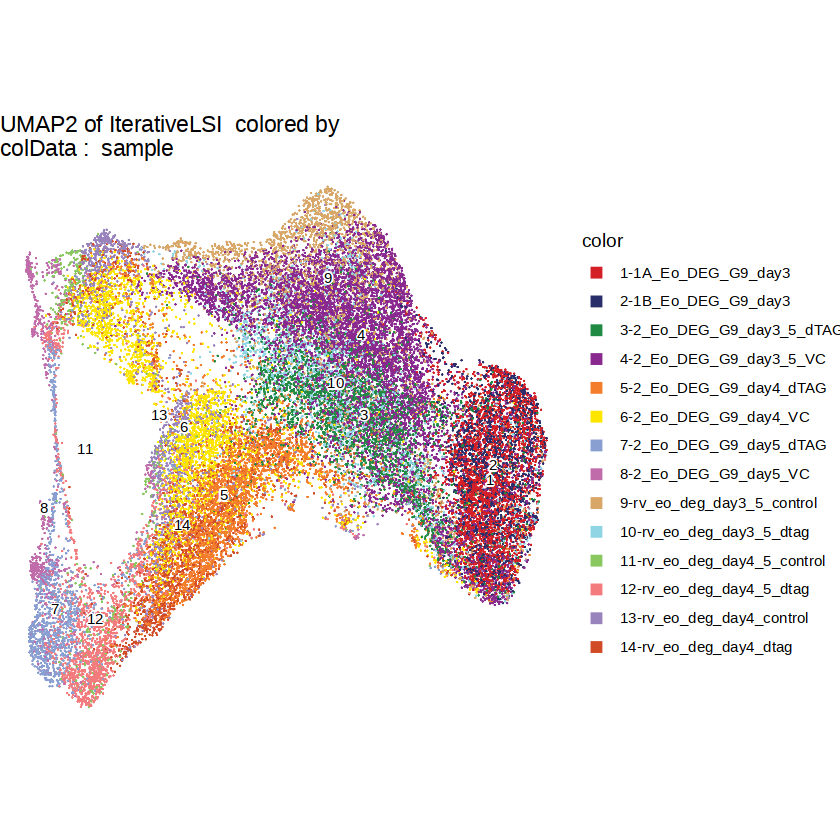

In [41]:
ArchRProject.filt <- addIterativeLSI(
    ArchRProj = ArchRProject.filt,
    useMatrix = "PeakMatrix", 
    name = "IterativeLSI2", 
    iterations = 4, 
    clusterParams = list( #See Seurat::FindClusters
        resolution = c(0.4, 1, 2), 
        sampleCells = 10000, 
    maxClusters=NULL, 
        n.start = 10
    ), 
    varFeatures = 20000, 
    dimsToUse = 1:20, 
    force = TRUE
)

ArchRProject.filt <- addUMAP(
    ArchRProj = ArchRProject.filt, 
    reducedDims = "IterativeLSI2", 
    name = "UMAP", 
    nNeighbors = 25, 
    minDist = 0.3, 
    metric = "cosine",
    force = TRUE
)

p1 <- plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "sample", embedding = "UMAP")

ArchRProject.filt <- addIterativeLSI(
    ArchRProj = ArchRProject.filt,
    useMatrix = "PeakMatrix", 
    name = "IterativeLSI", 
    iterations = 2, 
    clusterParams = list( #See Seurat::FindClusters
        resolution = c(2), 
        sampleCells = 10000, 
    maxClusters=NULL, 
        n.start = 10
    ), 
    varFeatures = 40000, 
    dimsToUse = 1:20,
    force = TRUE
)

ArchRProject.filt <- addUMAP(
    ArchRProj = ArchRProject.filt, 
    reducedDims = "IterativeLSI", 
    name = "UMAP2", 
    nNeighbors = 25, 
    minDist = 0.3, 
    metric = "cosine",
    force = TRUE
)

p2 <- plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "sample", embedding = "UMAP2")

p1 + theme_void()

p2 + theme_void()

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-2e7e21a93989-Date-2023-01-23_Time-14-12-28.log
If there is an issue, please report to github with logFile!

2023-01-23 14:12:37 : Computing Total Across All Features, 0.122 mins elapsed.

2023-01-23 14:12:41 : Computing Top Features, 0.182 mins elapsed.

###########
2023-01-23 14:12:42 : Running LSI (1 of 2) on Top Features, 0.2 mins elapsed.
###########

2023-01-23 14:12:42 : Sampling Cells (N = 10008) for Estimated LSI, 0.202 mins elapsed.

2023-01-23 14:12:42 : Creating Sampled Partial Matrix, 0.202 mins elapsed.

2023-01-23 14:13:03 : Computing Estimated LSI (projectAll = FALSE), 0.547 mins elapsed.

Filtering 1 dims correlated > 0.75 to log10(depth + 1)

2023-01-23 14:14:04 : Identifying Clusters, 1.563 mins elapsed.

2023-01-23 14:14:17 : Identified 22 Clusters, 1.792 mins elapsed.

2023-01-23 14:14:17 : Creating Cluster Matrix on the total Group Features, 1.793 mins elapsed.

2023-01-23 14:14:29 : Computing V

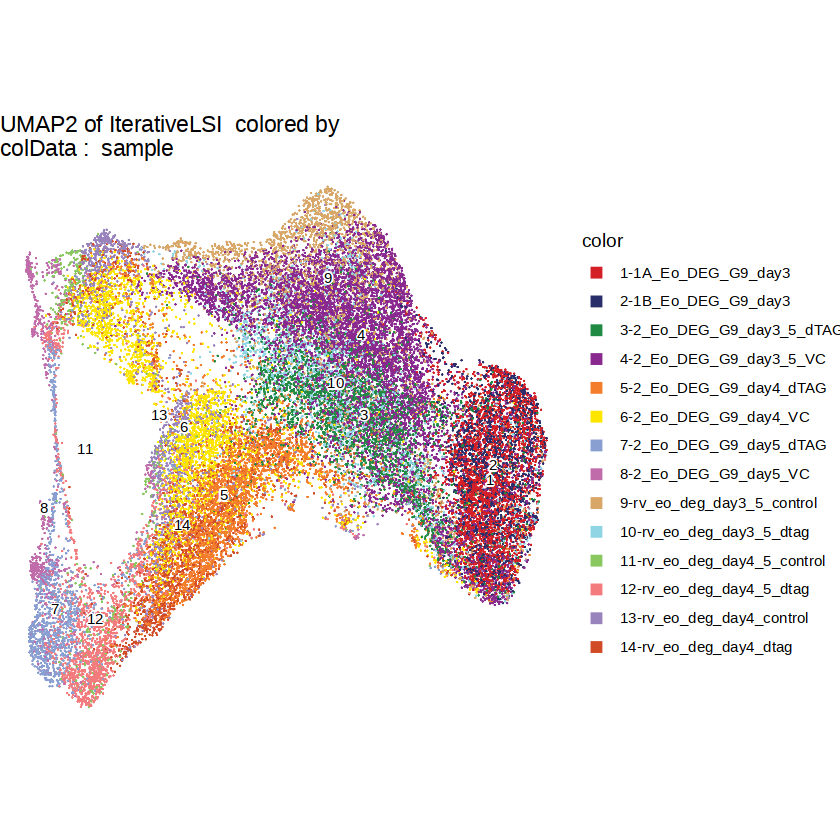

In [42]:
ArchRProject.filt <- addIterativeLSI(
  ArchRProj = ArchRProject.filt,
  useMatrix = 'PeakMatrix', 
  name = "IterativeLSI", 
  firstSelection = "Top",
  depthCol = "nFrags",
  iterations = 2, 
   clusterParams = list(
    resolution = 2, 
    sampleCells = 10000, 
    maxClusters=NULL,
    n.start = 10
   ), 
  saveIterations = FALSE,
  varFeatures = 25000, 
  dimsToUse = 1:25,
  force = TRUE
)

ArchRProject.filt <- addUMAP(
    ArchRProj = ArchRProject.filt, 
    reducedDims = "IterativeLSI2", 
    name = "UMAP", 
    nNeighbors = 25, 
    minDist = 0.3, 
    metric = "cosine",
    force = TRUE
)
 plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "sample", embedding = "UMAP2") + theme_void()

In [43]:
ArchRProject.filt@cellColData$celltype

[1] "Epiblast"                       "Primitive_Streak"              
    [3] "Epiblast"                       "Primitive_Streak"              
    [5] "Epiblast"                       "Primitive_Streak"              
    [7] "Primitive_Streak"               "Primitive_Streak"              
    [9] "Anterior_Primitive_Streak"      "Primitive_Streak"              
   [11] "Primitive_Streak"               "Primitive_Streak"              
   [13] "Primitive_Streak"               "Primitive_Streak"              
   [15] "Epiblast"                       "Epiblast"                      
   [17] "Anterior_Primitive_Streak"      "Epiblast"                      
   [19] "Primitive_Streak"               "Primitive_Streak"              
   [21] "Nascent_mesoderm"               "Primitive_Streak"              
   [23] "Epiblast"                       "Primitive_Streak"              
   [25] "Primitive_Streak"               "Primitive_Streak"              
   [27] "Anterior_Primitive_Streak"      "Primitive_Streak"              
   [29] "Primitive_Streak"               "Primitive_Streak"              
   [31] "Primitive_Streak"               "Primitive_Streak"              
   [33] "Primitive_Streak"               "Primitive_Streak"              
   [35] "Primitive_Streak"               "Primitive_Streak"              
   [37] "Primitive_Streak"               "Primitive_Streak"              
   [39] "Primitive_Streak"               "Primitive_Streak"              
   [41] "Anterior_Primitive_Streak"      "Anterior_Primitive_Streak"     
   [43] "Primitive_Streak"               "Primitive_Streak"              
   [45] "Primitive_Streak"               "Primitive_Streak"              
   [47] "Primitive_Streak"               "Anterior_Primitive_Streak"     
   [49] "Epiblast"                       "Primitive_Streak"              
   [51] "Primitive_Streak"               "Primitive_Streak"              
   [53] "Primitive_Streak"               "Primitive_Streak"              
   [55] "Primitive_Streak"               "Primitive_Streak"              
   [57] "Anterior_Primitive_Streak"      "Anterior_Primitive_Streak"     
   [59] "Epiblast"                       "Anterior_Primitive_Streak"     
   [61] "Nascent_mesoderm"               "Forebrain_Midbrain_Hindbrain"  
   [63] "Primitive_Streak"               "Primitive_Streak"              
   [65] "Anterior_Primitive_Streak"      "Epiblast"                      
   [67] "Anterior_Primitive_Streak"      "Primitive_Streak"              
   [69] "Primitive_Streak"               "Primitive_Streak"              
   [71] "Anterior_Primitive_Streak"      "Primitive_Streak"              
   [73] "Anterior_Primitive_Streak"      "Nascent_mesoderm"              
   [75] "Primitive_Streak"               "Primitive_Streak"              
   [77] "Primitive_Streak"               "Epiblast"                      
   [79] "Primitive_Streak"               "Primitive_Streak"              
   [81] "Epiblast"                       "Primitive_Streak"              
   [83] "Primitive_Streak"               "Primitive_Streak"              
   [85] "Anterior_Primitive_Streak"      "Primitive_Streak"              
   [87] "Primitive_Streak"               "Primitive_Streak"              
   [89] "Primitive_Streak"               "Primitive_Streak"              
   [91] "Primitive_Streak"               "Primitive_Streak"              
   [93] "Primitive_Streak"               "Epiblast"                      
   [95] "Rostral_neurectoderm"           "Primitive_Streak"              
   [97] "Primitive_Streak"               "Nascent_mesoderm"              
   [99] "Primitive_Streak"               "Anterior_Primitive_Streak"     
  [101] "Primitive_Streak"               "Primitive_Streak"              
  [103] "Primitive_Streak"               "Epiblast"                      
  [105] "Primitive_Streak"               "Primitive_Streak"              
  [107] "Epiblast"                       "Primitive_Streak"              
  [109] 

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-2e7e23b3edc-Date-2023-01-23_Time-14-17-15.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 
Length of unique values greater than palette, interpolating..



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-2e7e23b3edc-Date-2023-01-23_Time-14-17-15.log



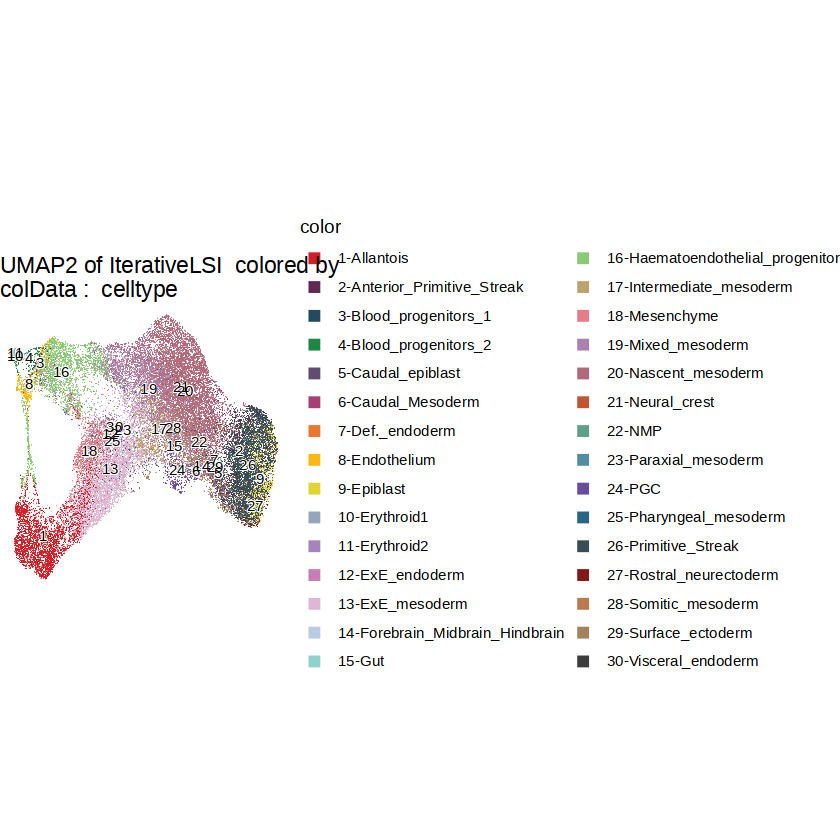

In [44]:
 plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "celltype", embedding = "UMAP2") + theme_void()

In [45]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code/atac/archR"

# Test clustering on LSI imported from previous code

In [48]:
dimredu = fread('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/dimensionality_reduction/cells/TileMatrix/remove_ExE_cells_FALSE/batch_correction_None/lsi_nfeatures35000_dims35.txt.gz')

In [49]:
head(dimredu)

cell,LSI1,LSI2,LSI3,LSI4,LSI6,LSI7,LSI8,LSI9,LSI10,⋯,LSI26,LSI27,LSI28,LSI29,LSI30,LSI31,LSI32,LSI33,LSI34,LSI35
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,5.416,1.145,0.126,0.642,-0.106,-0.547,-0.019,-0.550,-0.293,⋯,-0.347,-0.305,-0.336,-0.203,-0.225,-0.051,-0.144,-0.367,-0.325,0.022
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,5.513,1.007,0.061,0.629,-0.124,-0.328,-0.091,-0.376,-0.271,⋯,-0.158,-0.239,0.004,-0.334,-0.321,-0.227,-0.104,-0.156,-0.208,-0.362
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,5.372,1.071,0.102,0.824,0.057,-0.645,-0.255,-0.105,-0.354,⋯,-0.287,-0.206,-0.322,-0.101,-0.294,-0.220,-0.202,-0.254,-0.159,-0.040
1A_Eo_DEG_G9_day3#AAACATGCAATATACC-1,5.500,1.078,-0.053,0.733,-0.167,-0.438,-0.086,-0.409,-0.312,⋯,-0.040,-0.257,-0.233,-0.125,-0.424,-0.386,-0.322,-0.188,-0.191,-0.235
1A_Eo_DEG_G9_day3#AAACATGCAATCCTGA-1,5.446,1.025,-0.238,0.953,-0.092,-0.316,0.046,-0.488,-0.453,⋯,-0.198,-0.315,-0.147,-0.376,-0.377,-0.095,-0.232,-0.367,-0.281,-0.455
1A_Eo_DEG_G9_day3#AAACATGCACTTAGGC-1,5.439,1.010,-0.068,0.765,-0.089,-0.218,0.334,-0.635,-0.183,⋯,-0.414,0.008,-0.079,-0.451,-0.274,-0.106,-0.379,-0.208,-0.295,-0.390


In [65]:
test = dimredu %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% as.matrix()
head(test)

,LSI1,LSI2,LSI3,LSI4,LSI6,LSI7,LSI8,LSI9,LSI10,LSI11,⋯,LSI26,LSI27,LSI28,LSI29,LSI30,LSI31,LSI32,LSI33,LSI34,LSI35
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,5.416,1.145,0.126,0.642,-0.106,-0.547,-0.019,-0.550,-0.293,-0.081,⋯,-0.347,-0.305,-0.336,-0.203,-0.225,-0.051,-0.144,-0.367,-0.325,0.022
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,5.513,1.007,0.061,0.629,-0.124,-0.328,-0.091,-0.376,-0.271,-0.253,⋯,-0.158,-0.239,0.004,-0.334,-0.321,-0.227,-0.104,-0.156,-0.208,-0.362
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,5.372,1.071,0.102,0.824,0.057,-0.645,-0.255,-0.105,-0.354,-0.127,⋯,-0.287,-0.206,-0.322,-0.101,-0.294,-0.220,-0.202,-0.254,-0.159,-0.040
1A_Eo_DEG_G9_day3#AAACATGCAATATACC-1,5.500,1.078,-0.053,0.733,-0.167,-0.438,-0.086,-0.409,-0.312,-0.104,⋯,-0.040,-0.257,-0.233,-0.125,-0.424,-0.386,-0.322,-0.188,-0.191,-0.235
1A_Eo_DEG_G9_day3#AAACATGCAATCCTGA-1,5.446,1.025,-0.238,0.953,-0.092,-0.316,0.046,-0.488,-0.453,-0.172,⋯,-0.198,-0.315,-0.147,-0.376,-0.377,-0.095,-0.232,-0.367,-0.281,-0.455
1A_Eo_DEG_G9_day3#AAACATGCACTTAGGC-1,5.439,1.010,-0.068,0.765,-0.089,-0.218,0.334,-0.635,-0.183,-0.386,⋯,-0.414,0.008,-0.079,-0.451,-0.274,-0.106,-0.379,-0.208,-0.295,-0.390


In [78]:
test2 = list('matSVD' = test,
            'scaleDims' = FALSE)
#names(test2) = 'matSVD'

In [79]:
ArchRProject.filt@reducedDims$test = test2

In [81]:
ArchRProject.filt@reducedDims$IterativeLSI$matSVD = test

In [84]:
ArchRProject.filt <- addClusters(
    input = ArchRProject.filt,
    reducedDims = "IterativeLSI",
    method = "Seurat",
    name = paste0("Clusters_", args$matrix),
    resolution = 0.5
)

ArchR logging to : ArchRLogs/ArchR-addClusters-2e7e2e953a62-Date-2023-01-23_Time-14-35-35.log
If there is an issue, please report to github with logFile!

Filtering 1 dims correlated > 0.75 to log10(depth + 1)

2023-01-23 14:35:38 : Running Seurats FindClusters (Stuart et al. Cell 2019), 0.003 mins elapsed.

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 33177
Number of edges: 1094911

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8814
Number of communities: 13
Elapsed time: 8 seconds


2023-01-23 14:36:21 : Testing Biased Clusters, 0.733 mins elapsed.

2023-01-23 14:36:22 : Testing Outlier Clusters, 0.735 mins elapsed.

2023-01-23 14:36:22 : Assigning Cluster Names to 13 Clusters, 0.735 mins elapsed.

2023-01-23 14:36:22 : Finished addClusters, 0.737 mins elapsed.



In [92]:
test = ArchRProject.filt@cellColData %>% as.data.table(.,keep.rownames=T) %>% setnames('rn', ' cell')
head(test$)

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


cell,Sample,TSSEnrichment,ReadsInTSS,ReadsInPromoter,ReadsInBlacklist,PromoterRatio,PassQC,NucleosomeRatio,nMultiFrags,⋯,TSSEnrichment_atac,ReadsInTSS_atac,PromoterRatio_atac,NucleosomeRatio_atac,nFrags_atac,BlacklistRatio_atac,ReadsInPeaks,FRIP,Clusters,Clusters_
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,1A_Eo_DEG_G9_day3,14.253,5607,21713,1905,0.2212001,1,1.191756,11856,⋯,14.25,5607,0.22,1.19,49080,0.02,39259,0.4004059,C9,C5
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,1A_Eo_DEG_G9_day3,11.474,3998,15951,1807,0.1715272,1,1.559844,12187,⋯,11.47,3998,0.17,1.56,46497,0.02,28549,0.3071899,C9,C5
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,1A_Eo_DEG_G9_day3,14.695,10775,41345,3519,0.2477945,1,1.267072,20992,⋯,14.70,10775,0.25,1.27,83426,0.02,70338,0.4221158,C10,C6
1A_Eo_DEG_G9_day3#AAACATGCAATATACC-1,1A_Eo_DEG_G9_day3,13.452,3349,12977,1047,0.2148795,1,1.482407,7888,⋯,13.45,3349,0.21,1.48,30196,0.02,22808,0.3779663,C9,C5
1A_Eo_DEG_G9_day3#AAACATGCAATCCTGA-1,1A_Eo_DEG_G9_day3,11.985,1392,5520,521,0.2051282,1,1.483389,3475,⋯,11.98,1392,0.21,1.48,13455,0.02,9506,0.3534355,C9,C5
1A_Eo_DEG_G9_day3#AAACATGCACTTAGGC-1,1A_Eo_DEG_G9_day3,13.134,1101,4315,351,0.2316157,1,1.332832,2275,⋯,13.13,1101,0.23,1.33,9315,0.02,7715,0.4145175,C9,C5


In [96]:
colnames(meta)[length(colnames(meta))]

[1] "pass_atacQC"

In [107]:
test = meta[,test:=assign(colnames(meta)[length(colnames(meta))])]
head(test)

ERROR: Error in assign(colnames(meta)[length(colnames(meta))]): argument "value" is missing, with no default


ArchR logging to : ArchRLogs/ArchR-plotEmbedding-2e7e21450a02-Date-2023-01-23_Time-14-38-17.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-2e7e21450a02-Date-2023-01-23_Time-14-38-17.log



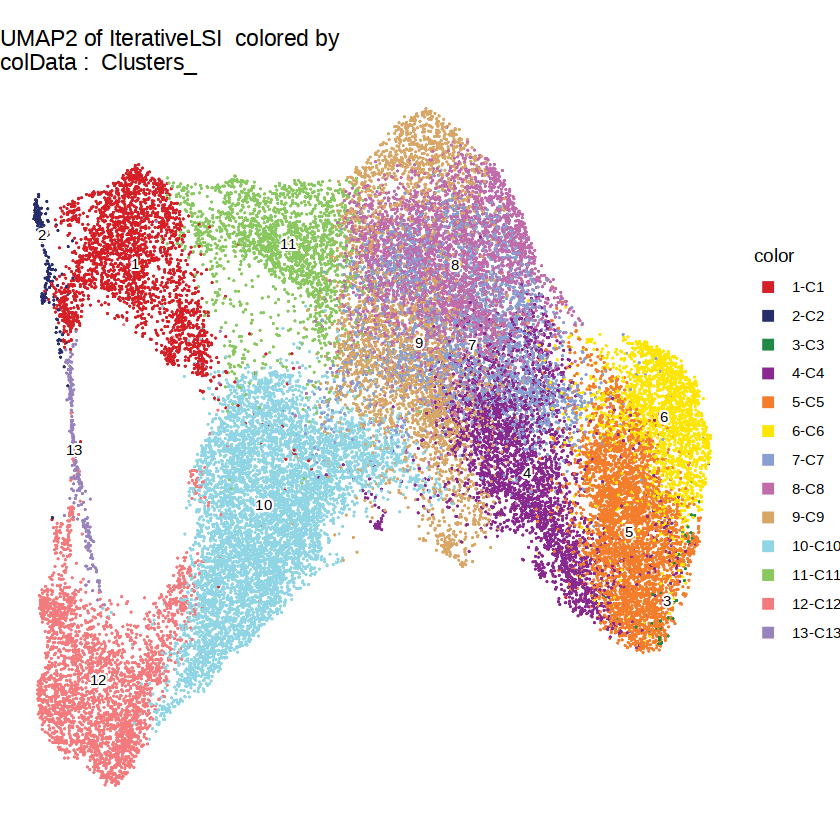

In [87]:
 plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "Clusters_", embedding = "UMAP2") + theme_void()

In [27]:
sample_metadata <- fread('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/rna/qc/sample_metadata_after_qc.txt.gz')

In [115]:
setwd(args$archr_directory)

addArchRGenome("mm10")
addArchRThreads(threads = 1)

ArchRProject <- loadArchRProject(args$archr_directory)#[sample_metadata$cell]

Setting default genome to Mm10.

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__

In [139]:
# print stats
print(sprintf("Number of cells that are derived from the ATAC pipeline (before QC): %s",length(rownames(ArchRProject))))
print(sprintf("Number of cells that are derived from the RNA pipeline (before QC): %s",nrow(sample_metadata)))
print(sprintf("Number of cells that are derived from the RNA pipeline but are not present in the ArchR project: %s",sum(!sample_metadata$cell%in%rownames(ArchRProject))))
print(table(sample_metadata[!cell%in%rownames(ArchRProject),sample]))
print(rownames(ArchRProject@cellColData)[!rownames(ArchRProject@cellColData)%in%sample_metadata$cell] %>% strsplit("#") %>% map_chr(1) %>% table)
print(sprintf("Number of cells that are derived from the ArchR project but are not present in the RNA pipeline: %s",sum(!rownames(ArchRProject@cellColData)%in%sample_metadata$cell)))
print(rownames(ArchRProject@cellColData)[!rownames(ArchRProject@cellColData)%in%sample_metadata$cell] %>% strsplit("#") %>% map_chr(1) %>% table)

nrow(sample_metadata[sample=="rv_eo_deg_day3_5_control"])
nrow(sample_metadata[pass_rnaQC==T & sample=="rv_eo_deg_day3_5_control"])
tmp <- sample_metadata[sample=="rv_eo_deg_day3_5_control" & !cell%in%rownames(ArchRProject@cellColData)]
tmp = sample_metadata[pass_rnaQC==T & !cell%in%rownames(ArchRProject@cellColData)]

[1] "Number of cells that are derived from the ATAC pipeline (before QC): 0"
[1] "Number of cells that are derived from the RNA pipeline (before QC): 86842"
[1] "Number of cells that are derived from the RNA pipeline but are not present in the ArchR project: 86842"

       1A_Eo_DEG_G9_day3        1B_Eo_DEG_G9_day3  2_Eo_DEG_G9_day3_5_dTAG 
                    7337                     2789                     5758 
   2_Eo_DEG_G9_day3_5_VC    2_Eo_DEG_G9_day4_dTAG      2_Eo_DEG_G9_day4_VC 
                   11898                     4811                     4667 
   2_Eo_DEG_G9_day5_dTAG      2_Eo_DEG_G9_day5_VC rv_eo_deg_day3_5_control 
                    1740                     2625                     9741 
   rv_eo_deg_day3_5_dtag rv_eo_deg_day4_5_control    rv_eo_deg_day4_5_dtag 
                   14069                     1893                     5363 
  rv_eo_deg_day4_control      rv_eo_deg_day4_dtag 
                   10031                     4120 
.
       1A_Eo_DEG_G9_d

[1] 9741

[1] 3138

In [123]:
head(sample_metadata)

cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,alias,day,genotype,pass_rnaQC
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>
rv_eo_deg_day3_5_control#AAACAGCCAAACCTTG-1,AAACAGCCAAACCTTG-1,rv_eo_deg_day3_5_control,5674,22142,9.80,10.84,day3.5_wt_rep1,D3.5,wt,TRUE
rv_eo_deg_day3_5_control#AAACAGCCAAGTGTTT-1,AAACAGCCAAGTGTTT-1,rv_eo_deg_day3_5_control,845,1498,2.34,26.37,day3.5_wt_rep1,D3.5,wt,FALSE
rv_eo_deg_day3_5_control#AAACAGCCAGCAACCT-1,AAACAGCCAGCAACCT-1,rv_eo_deg_day3_5_control,5132,18136,10.76,10.37,day3.5_wt_rep1,D3.5,wt,TRUE
rv_eo_deg_day3_5_control#AAACAGCCAGGAACTG-1,AAACAGCCAGGAACTG-1,rv_eo_deg_day3_5_control,661,1077,4.64,26.18,day3.5_wt_rep1,D3.5,wt,FALSE
rv_eo_deg_day3_5_control#AAACAGCCAGGCCTTG-1,AAACAGCCAGGCCTTG-1,rv_eo_deg_day3_5_control,735,1276,2.59,24.53,day3.5_wt_rep1,D3.5,wt,FALSE
rv_eo_deg_day3_5_control#AAACAGCCAGGGAGCT-1,AAACAGCCAGGGAGCT-1,rv_eo_deg_day3_5_control,666,1069,6.64,24.32,day3.5_wt_rep1,D3.5,wt,FALSE


In [136]:
print(rownames(ArchRProject@cellColData)[!rownames(ArchRProject@cellColData)%in%sample_metadata$cell] %>% strsplit("#") %>% map_chr(1) %>% table)

.
       1A_Eo_DEG_G9_day3        1B_Eo_DEG_G9_day3  2_Eo_DEG_G9_day3_5_dTAG 
                     386                      883                      690 
   2_Eo_DEG_G9_day3_5_VC    2_Eo_DEG_G9_day4_dTAG      2_Eo_DEG_G9_day4_VC 
                     245                     5293                      598 
   2_Eo_DEG_G9_day5_dTAG      2_Eo_DEG_G9_day5_VC rv_eo_deg_day3_5_control 
                    1408                      152                      735 
   rv_eo_deg_day3_5_dtag rv_eo_deg_day4_5_control    rv_eo_deg_day4_5_dtag 
                     346                     4227                      445 
  rv_eo_deg_day4_control      rv_eo_deg_day4_dtag 
                     769                      777 


In [2]:
library(data.table)

In [7]:
test = fread('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/qc/sample_metadata_after_qc.txt.gz')

In [8]:
head(test)

cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,alias,day,genotype,pass_rnaQC,doublet_score,doublet_call,TSSEnrichment_atac,ReadsInTSS_atac,PromoterRatio_atac,NucleosomeRatio_atac,nFrags_atac,BlacklistRatio_atac,pass_atacQC
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>,<dbl>,<lgl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<lgl>
1A_Eo_DEG_G9_day3#AAACAGCCAAGTGAAC-1,AAACAGCCAAGTGAAC-1,1A_Eo_DEG_G9_day3,602,1007,0.50,25.02,day3_wt_rep1,D3,wt,FALSE,NA,NA,NA,NA,NA,NA,NA,NA,FALSE
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,AAACAGCCAGCAAGAT-1,1A_Eo_DEG_G9_day3,6110,22923,6.09,10.15,day3_wt_rep1,D3,wt,TRUE,1.15,FALSE,14.25,5607,0.22,1.19,49080,0.02,TRUE
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,AAACAGCCAGCACCAT-1,1A_Eo_DEG_G9_day3,4201,10794,6.57,7.38,day3_wt_rep1,D3,wt,TRUE,0.53,FALSE,11.47,3998,0.17,1.56,46497,0.02,TRUE
1A_Eo_DEG_G9_day3#AAACATGCAACACCTA-1,AAACATGCAACACCTA-1,1A_Eo_DEG_G9_day3,680,1195,2.68,23.51,day3_wt_rep1,D3,wt,FALSE,NA,NA,NA,NA,NA,NA,NA,NA,FALSE
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,AAACATGCAAGTAAGC-1,1A_Eo_DEG_G9_day3,3659,8745,5.74,11.92,day3_wt_rep1,D3,wt,TRUE,0.31,FALSE,14.70,10775,0.25,1.27,83426,0.02,TRUE
1A_Eo_DEG_G9_day3#AAACATGCAATATACC-1,AAACATGCAATATACC-1,1A_Eo_DEG_G9_day3,3640,8461,3.70,7.21,day3_wt_rep1,D3,wt,TRUE,0.16,FALSE,13.45,3349,0.21,1.48,30196,0.02,TRUE


In [14]:
nrow(test[pass_atacQC==TRUE & doublet_call==FALSE])
nrow(test[pass_atacQC==TRUE & is.na(doublet_call)])
nrow(test[pass_atacQC==TRUE & doublet_call==FALSE | pass_atacQC==TRUE & is.na(doublet_call)])


[1] 33177

[1] 2359

[1] 35536

In [ ]:
/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/rna/qc/sample_metadata_after_doublets.txt.gz
/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/rna/doublet_detection/sample_metadata_after_doublets.txt.gz

In [156]:
test = fread('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/qc/qc_TSSenrichment.txt.gz')

In [164]:
unique(test$variable)

[1] "value"       "normValue"   "smoothValue"

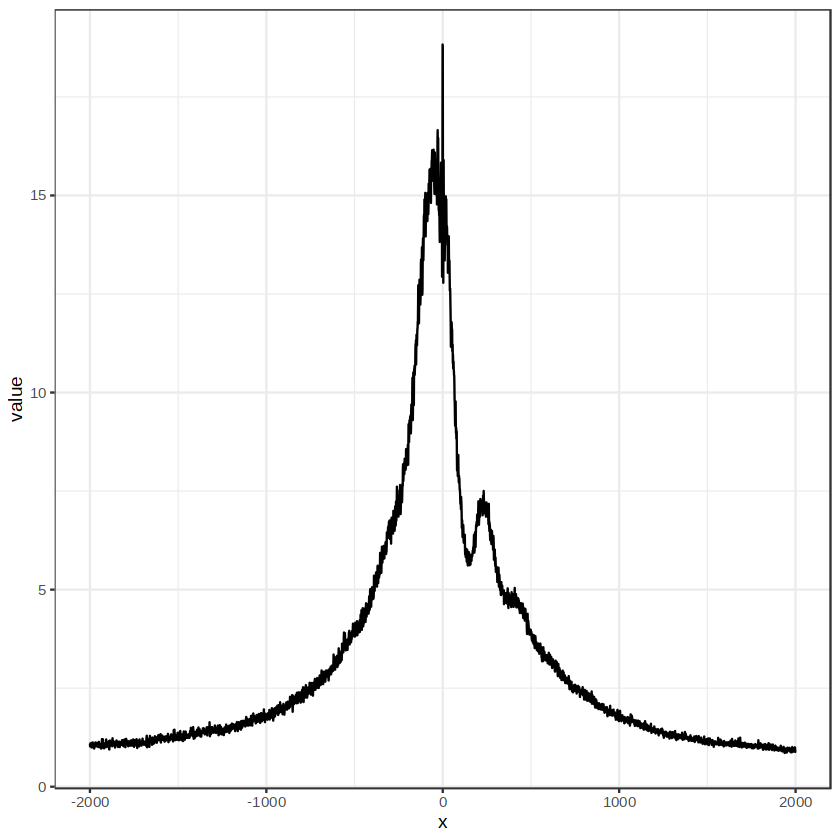

In [165]:
ggplot(test[sample=='rv_eo_deg_day3_5_control' & variable=='normValue'], aes(x, value)) + 
    geom_line() + theme_bw()

In [22]:
ArchRProject.filt <- addIterativeLSI(
  ArchRProj = ArchRProject.filt,
  useMatrix = 'PeakMatrix', 
  name = "IterativeLSI", 
  firstSelection = "Top",
  depthCol = "nFrags",
  iterations = 2, 
   clusterParams = list(
    resolution = 2, 
    sampleCells = 10000, 
    maxClusters=NULL,
    n.start = 10
   ), 
  saveIterations = FALSE,
  varFeatures = 5000, 
  dimsToUse = 1:15,
  force = TRUE
)

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-3f2f23d53c0-Date-2023-01-24_Time-10-56-43.log
If there is an issue, please report to github with logFile!

2023-01-24 10:58:22 : Computing Total Across All Features, 1.455 mins elapsed.

2023-01-24 10:58:27 : Computing Top Features, 1.532 mins elapsed.

###########
2023-01-24 10:58:27 : Running LSI (1 of 2) on Top Features, 1.544 mins elapsed.
###########

2023-01-24 10:58:27 : Sampling Cells (N = 10008) for Estimated LSI, 1.545 mins elapsed.

2023-01-24 10:58:27 : Creating Sampled Partial Matrix, 1.545 mins elapsed.

2023-01-24 10:59:37 : Computing Estimated LSI (projectAll = FALSE), 2.708 mins elapsed.

Filtering 1 dims correlated > 0.75 to log10(depth + 1)

2023-01-24 10:59:58 : Identifying Clusters, 3.048 mins elapsed.

2023-01-24 11:00:25 : Identified 19 Clusters, 3.512 mins elapsed.

2023-01-24 11:00:25 : Creating Cluster Matrix on the total Group Features, 3.512 mins elapsed.

2023-01-24 11:01:40 : Computing 

In [83]:
addArchRThreads(16)

Setting default number of Parallel threads to 16.



In [84]:
ArchRProject.filt <- addIterativeLSI(
  ArchRProj = ArchRProject.filt,
  useMatrix = 'PeakMatrix', 
  name = "IterativeLSI", 
  firstSelection = "Top",
  depthCol = "nFrags",
  iterations = 2, 
   clusterParams = list(
    resolution = 2, 
    sampleCells = 10000, 
    maxClusters=NULL,
    n.start = 10
   ), 
  saveIterations = FALSE,
  varFeatures = 5000, 
  dimsToUse = 1:15,
  force = TRUE
)

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-3f2f2632a979b-Date-2023-01-24_Time-11-35-46.log
If there is an issue, please report to github with logFile!

2023-01-24 11:35:49 : Computing Total Across All Features, 0.008 mins elapsed.

2023-01-24 11:35:52 : Computing Top Features, 0.057 mins elapsed.

###########
2023-01-24 11:35:53 : Running LSI (1 of 2) on Top Features, 0.076 mins elapsed.
###########

2023-01-24 11:35:53 : Sampling Cells (N = 10008) for Estimated LSI, 0.078 mins elapsed.

2023-01-24 11:35:53 : Creating Sampled Partial Matrix, 0.078 mins elapsed.

2023-01-24 11:36:02 : Computing Estimated LSI (projectAll = FALSE), 0.232 mins elapsed.

Filtering 1 dims correlated > 0.75 to log10(depth + 1)

2023-01-24 11:36:25 : Identifying Clusters, 0.604 mins elapsed.

2023-01-24 11:36:35 : Identified 16 Clusters, 0.783 mins elapsed.

2023-01-24 11:36:35 : Creating Cluster Matrix on the total Group Features, 0.783 mins elapsed.

2023-01-24 11:36:46 : Computin

In [24]:
lsi.mtx <- getReducedDims(ArchRProject.filt, "IterativeLSI")
#lsi.mtx <- lsi.mtx[,which(abs(cor(lsi.mtx,sample_metadata$nFrags_atac))<=0.75)]

In [25]:
head(lsi.mtx)

,LSI1,LSI2,LSI3,LSI4,LSI5,LSI6,LSI7,LSI8,LSI9,LSI10,LSI11,LSI12,LSI13,LSI14,LSI15
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,-3.402920,-0.7644839,0.6058116,-0.09759881,0.6496939,0.2421177,0.14422287,0.2372824,0.28353309,0.2383889,0.1773770,0.3896291,0.3242345,0.4500637,0.5226480
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,-3.448468,-0.6626525,0.5389670,-0.18559091,0.4404043,0.2595111,0.32990722,0.2648884,0.20442901,0.3405783,0.3720860,0.3681645,0.3421748,0.3641886,0.4714123
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,-3.378931,-0.7644258,0.5182552,-0.08939354,0.9183621,0.2193506,0.07881355,0.2711479,0.38286832,0.1951503,0.3272252,0.2448630,0.2678985,0.3975221,0.4112936
1A_Eo_DEG_G9_day3#AAACATGCAATATACC-1,-3.414052,-0.7661154,0.5791988,-0.16855318,0.3971838,0.2435482,0.26507710,0.2485707,0.21489092,0.3460703,0.2688443,0.4612587,0.5167101,0.4182434,0.3891238
1A_Eo_DEG_G9_day3#AAACATGCAATCCTGA-1,-3.404798,-0.6155720,0.8225246,-0.35212648,0.2111506,0.2641046,0.37938668,0.3560537,0.16797705,0.3152904,0.3780379,0.2559937,0.3419954,0.4038022,0.4761801
1A_Eo_DEG_G9_day3#AAACATGCACTTAGGC-1,-3.411734,-0.7018810,0.6450416,-0.21736351,0.5153536,0.2630021,0.37249935,0.2201849,0.06557753,0.3247637,0.2360215,0.4120809,0.3929414,0.4091852,0.4743268


In [28]:
sample_metadata = sample_metadata[,exp:=str_replace_all(sample, opts$sample2exp)]

In [29]:
head(sample_metadata)

cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,alias,day,genotype,pass_rnaQC,exp
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>,<chr>
rv_eo_deg_day3_5_control#AAACAGCCAAACCTTG-1,AAACAGCCAAACCTTG-1,rv_eo_deg_day3_5_control,5674,22142,9.80,10.84,day3.5_wt_rep1,D3.5,wt,TRUE,exp1
rv_eo_deg_day3_5_control#AAACAGCCAAGTGTTT-1,AAACAGCCAAGTGTTT-1,rv_eo_deg_day3_5_control,845,1498,2.34,26.37,day3.5_wt_rep1,D3.5,wt,FALSE,exp1
rv_eo_deg_day3_5_control#AAACAGCCAGCAACCT-1,AAACAGCCAGCAACCT-1,rv_eo_deg_day3_5_control,5132,18136,10.76,10.37,day3.5_wt_rep1,D3.5,wt,TRUE,exp1
rv_eo_deg_day3_5_control#AAACAGCCAGGAACTG-1,AAACAGCCAGGAACTG-1,rv_eo_deg_day3_5_control,661,1077,4.64,26.18,day3.5_wt_rep1,D3.5,wt,FALSE,exp1
rv_eo_deg_day3_5_control#AAACAGCCAGGCCTTG-1,AAACAGCCAGGCCTTG-1,rv_eo_deg_day3_5_control,735,1276,2.59,24.53,day3.5_wt_rep1,D3.5,wt,FALSE,exp1
rv_eo_deg_day3_5_control#AAACAGCCAGGGAGCT-1,AAACAGCCAGGGAGCT-1,rv_eo_deg_day3_5_control,666,1069,6.64,24.32,day3.5_wt_rep1,D3.5,wt,FALSE,exp1


In [35]:
correction_order = as.data.table(table(sample_metadata$exp))[order(-N), V1]
sample_metadata = sample_metadata[cell %in% rownames(lsi.mtx)]

LSI.list = lapply(correction_order, function(x){
    tmp = lsi.mtx[sample_metadata$exp == x,]
    return(tmp)
})

In [69]:
lsi.mtx <- reducedMNN(LSI.list, merge.order=1:length(LSI.list))$corrected 

In [70]:
head(lsi.mtx)

,LSI1,LSI2,LSI3,LSI4,LSI5,LSI6,LSI7,LSI8,LSI9,LSI10,LSI11,LSI12,LSI13,LSI14,LSI15
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,-3.406587,-0.7860386,0.6255883,-0.1002749,0.6140560,0.2655749,0.116449431,0.2771842,0.26920871,0.2737105,0.1639773,0.4154200,0.2882597,0.4692075,0.5142643
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,-3.451967,-0.6832186,0.5578366,-0.1881443,0.4064009,0.2818924,0.303407577,0.3029602,0.19076161,0.3742799,0.3593008,0.3927725,0.3078499,0.3824543,0.4634131
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,-3.388861,-0.8227902,0.5718053,-0.0966398,0.8218640,0.2828664,0.003610435,0.3791916,0.34408171,0.2907919,0.2909423,0.3146979,0.1704883,0.4493583,0.3885927
1A_Eo_DEG_G9_day3#AAACATGCAATATACC-1,-3.415758,-0.7761431,0.5883993,-0.1697982,0.3806043,0.2544609,0.252156360,0.2671338,0.20822694,0.3625026,0.2626105,0.4732572,0.4999740,0.4271495,0.3852235
1A_Eo_DEG_G9_day3#AAACATGCAATCCTGA-1,-3.403132,-0.6057794,0.8135397,-0.3509107,0.2273415,0.2534476,0.392004644,0.3379255,0.17448486,0.2992432,0.3841257,0.2442765,0.3583393,0.3951048,0.4799890
1A_Eo_DEG_G9_day3#AAACATGCACTTAGGC-1,-3.414937,-0.7207046,0.6623125,-0.2197006,0.4842312,0.2834871,0.348244941,0.2550310,0.05306813,0.3556099,0.2243196,0.4346040,0.3615248,0.4259033,0.4670054


In [78]:
args$lsi_iterations = 4

In [79]:
if(args$lsi_iterations == 2){
    opts$lsi.cluster.resolution = 2
}else if(args$lsi_iterations == 3){
    opts$lsi.cluster.resolution = c(1,2)
}else if(args$lsi_iterations == 4){
    opts$lsi.cluster.resolution = c(0.4, 1, 2)
}
    opts$lsi.cluster.resolution

[1] 0.4 1.0 2.0

In [8]:
args$metadata = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/qc/sample_metadata_after_qc.txt.gz'

In [9]:
##########################
## Load sample metadata ##
##########################

sample_metadata <- fread(args$metadata) %>%
  # .[pass_atacQC==TRUE & doublet_call==FALSE & sample%in%args$samples] %>%
  # .[nFrags_atac>=3500 & TSSEnrichment_atac>=9,pass_atacQC:=TRUE] %>% .[stage=="E8.7",stage:="E8.75"] %>%    # temporary
  .[pass_atacQC==TRUE & doublet_call==FALSE | pass_atacQC==TRUE & is.na(doublet_call)] %>%
  .[,log_nFrags_atac:=log10(nFrags_atac)]
  
stopifnot(args$colour_by %in% colnames(sample_metadata))



table(sample_metadata$day)
#table(sample_metadata$celltype)

########################
## Load ArchR project ##
########################

source(here::here("atac/archR/load_archR_project.R"))

# Subset
ArchRProject.filt <- ArchRProject[sample_metadata$cell]
# ArchRProject.filt@sampleColData <- ArchRProject.filt@sampleColData[args$samples,,drop=F]

###################
## Sanity checks ##
###################

stopifnot(args$matrix %in% getAvailableMatrices(ArchRProject))

if (args$batch_variable!='None') {
  stopifnot(args$batch_variable%in%colnames(sample_metadata))
  if (length(unique(sample_metadata[[args$batch_variable]]))==1) {
    message(sprintf("There is a single level for %s, no batch correction applied",args$batch_variable))
    args$batch_variable <- NULL
  } else {
    library(batchelor)
  }
}

if (length(args$vars_to_regress)>0) {
  stopifnot(args$vars_to_regress%in%colnames(sample_metadata))
}



   D3  D3.5    D4  D4.5    D5 
 4890 15727  9854  2312  2134 

Setting default genome to Mm10.

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__

ERROR: Error in if (args$batch_variable != "None") {: argument is of length zero


In [92]:
getAvailableMatrices(ArchRProject.filt)

[1] "DeviationMatrix_CISBP"  "DeviationMatrix_JASPAR" "GeneScoreMatrix_TSS"   
[4] "GeneScoreMatrix_distal" "PeakMatrix"             "PeakMatrix_atlas"      
[7] "TileMatrix"

In [10]:
test = getMatrixFromProject(ArchRProject, 'DeviationMatrix_CISBP')

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-7a8c3bea09a8-Date-2023-01-24_Time-16-44-05.log
If there is an issue, please report to github with logFile!

2023-01-24 16:44:42 : Organizing colData, 0.609 mins elapsed.

2023-01-24 16:44:42 : Organizing rowData, 0.622 mins elapsed.

2023-01-24 16:44:42 : Organizing rowRanges, 0.622 mins elapsed.

2023-01-24 16:44:42 : Organizing Assays (1 of 2), 0.622 mins elapsed.

2023-01-24 16:44:47 : Organizing Assays (2 of 2), 0.704 mins elapsed.

2023-01-24 16:44:52 : Constructing SummarizedExperiment, 0.775 mins elapsed.

2023-01-24 16:44:52 : Finished Matrix Creation, 0.786 mins elapsed.



In [14]:
test2 = round(test@assays@data$z, 2)

In [16]:
test3 = test2[rowVars(test2)>1.5,]
dim(test3)

[1]   546 33177

In [22]:
pca = irlba::prcomp_irlba(test3, n = 15)

In [65]:
library(uwot)

In [79]:
umap = as.data.table(umap(pca$x, min_dist=0.3, n_neighbors=20)) %>%
    setnames(c('umap1', 'umap2')) %>%
    .[,TF:=strsplit(rownames(test2), '_') %>% map_chr(1)]

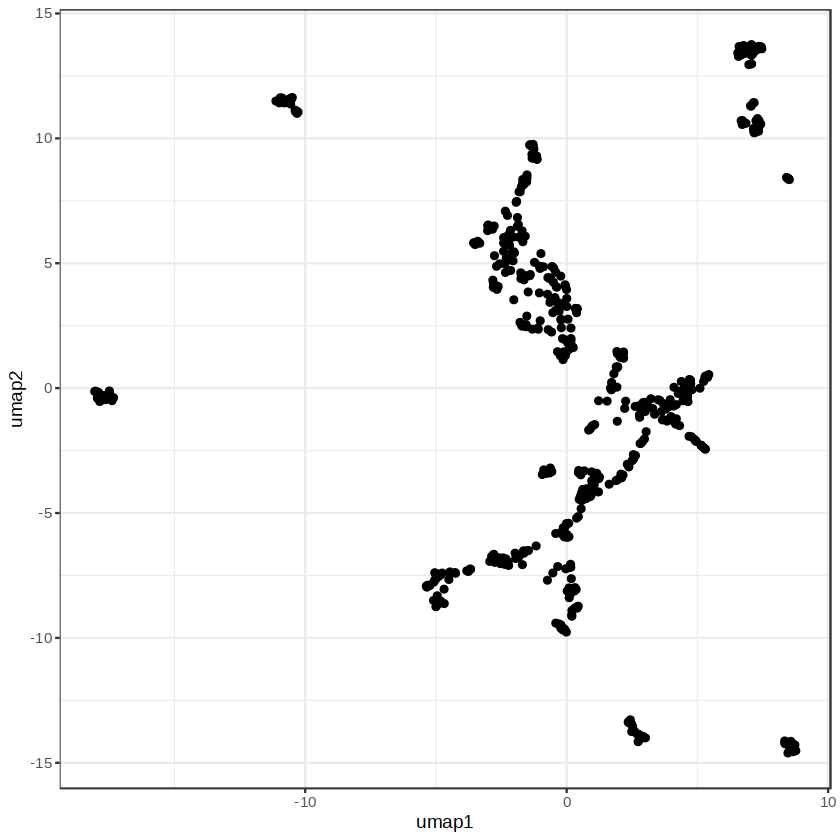

In [98]:
labels = umap[TF %in% c('Tcfap2a', 'Gata1', 'Eomes', 'Etv2', 'Sox4', 'Foxa2')]
ggplot(umap, aes(umap1, umap2, label=TF)) + 
    geom_point() + 
   # geom_label(data = labels) +
    theme_bw()

In [17]:
head(test3)

  [[ suppressing 34 column names ‘2_Eo_DEG_G9_day3_5_VC#CTACGAAGTGAGCACT-1’, ‘2_Eo_DEG_G9_day3_5_VC#TGGACAAAGCTCAATA-1’, ‘2_Eo_DEG_G9_day3_5_VC#GTGAGCGAGCTCCTAC-1’ ... ]]



6 x 33177 sparse Matrix of class "dgCMatrix"
                                                                          
Tcfap2a_1  0.09  0.71 -0.31 -0.59  0.00  0.16 -0.60  0.63 -1.08 -1.93 1.29
Tcfap2b_2 -0.35  0.12  1.00 -0.38 -2.18  0.89  0.65 -0.96  1.10 -0.08 1.12
Tcfap2e_4  0.65  1.12 -0.61  0.37 -1.60  0.51  1.68  0.47  0.06  0.19 1.26
Arid3b_6   1.04 -0.10  0.23 -0.12  1.60 -0.15  1.33 -0.35  0.11 -0.71 1.59
Arid3a_7  -0.39  0.48 -0.06  1.05  2.18  0.08  1.73 -0.08 -0.06 -0.41 1.29
Arid5a_9  -0.18  0.47  0.24  0.08  0.18  0.59 -0.04 -0.11 -0.27  0.31 0.45
                                                                           
Tcfap2a_1  1.16 -1.08 -0.11 -0.08 -0.48 -0.73 -1.04 -2.20  4.15 -0.85  2.25
Tcfap2b_2  3.22 -1.29 -0.44  0.36 -2.09 -0.75 -0.97 -1.66  6.16  0.43  3.02
Tcfap2e_4  2.16 -1.77  0.73  0.88 -1.24 -0.64 -0.66 -1.45  5.07 -0.27  2.03
Arid3b_6  -0.21  1.49  1.17 -0.53  1.19  0.48 -0.87 -1.69 -0.30  0.07 -0.72
Arid3a_7  -0.41  0.42  2.10 -0.79  1.99  0.89 -1.8

In [ ]:
dist = dist(t(test3))

In [ ]:
dist2 = as.matrix(dist)

In [ ]:
pca = irlba::prcomp_irlba(dist2, n = 15)

In [ ]:
head(pca$x)

In [ ]:
ggplot(as.data.frame(pca$x), aes(PC1, PC2)) + 
    geom_point()

In [24]:
test10 = readRDS('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/dimensionality_reduction/cells/TileMatrix/remove_ExE_cells_FALSE/batch_correction_None/lsi_nfeatures20000_dims30.rds')

In [25]:
test10

List of length 18
names(18): matSVD rowSm nCol exclude ... scaleDims useMatrix tileSize

In [ ]:
Rscript ../dimensionality_reduction/cells/archR_clustering.R --metadata /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/qc/sample_metadata_after_qc.txt.gz --reduced_dim /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/dimensionality_reduction/cells/TileMatrix/remove_ExE_cells_FALSE/batch_correction_None/lsi_nfeatures20000_dims30.rds --matrix TileMatrix  --cluster_resolution 0.5          --outfile /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/qc/sample_metadata_update.txt.gz --threads 16 > logs/archR_clustering_TileMatrix.log

In [46]:
args$metadata = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/qc/sample_metadata_after_qc.txt.gz'
args$reduced_dim = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/dimensionality_reduction/cells/TileMatrix/remove_ExE_cells_FALSE/batch_correction_None/lsi_nfeatures20000_dims30.rds'
args$cluster_resolution = 0.5
args$matrix = 'TileMatrix'

In [28]:

sample_metadata <- fread(args$metadata) %>%
  .[pass_atacQC==TRUE & doublet_call==FALSE | pass_atacQC==TRUE & is.na(doublet_call)]

reduced_dim = readRDS(args$reduced_dim)

########################
## Load ArchR project ##
########################

source(here::here("atac/archR/load_archR_project.R"))

# Subset
ArchRProject.filt <- ArchRProject[sample_metadata$cell]



Setting default genome to Mm10.

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__

In [33]:
dim(reduced_dim$matSVD)

[1] 35536    30

In [34]:
nrow(sample_metadata)

[1] 35536

In [36]:
################
## Clustering ##
################

ArchRProject.filt@reducedDims$IterativeLSI = reduced_dim

ArchRProject.filt <- addClusters(
    input = ArchRProject.filt,
    reducedDims = "IterativeLSI",
    method = "Seurat",
    name = "Clusters",
    resolution = args$cluster_resolution
)

ArchR logging to : ArchRLogs/ArchR-addClusters-1a376089e342-Date-2023-01-24_Time-14-25-49.log
If there is an issue, please report to github with logFile!

Filtering 1 dims correlated > 0.75 to log10(depth + 1)

2023-01-24 14:25:53 : Running Seurats FindClusters (Stuart et al. Cell 2019), 0.004 mins elapsed.

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 35536
Number of edges: 1180834

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8791
Number of communities: 12
Elapsed time: 6 seconds


1 singletons identified. 11 final clusters.

2023-01-24 14:26:35 : Testing Biased Clusters, 0.71 mins elapsed.

2023-01-24 14:26:35 : Testing Outlier Clusters, 0.711 mins elapsed.

2023-01-24 14:26:35 : Assigning Cluster Names to 11 Clusters, 0.711 mins elapsed.

2023-01-24 14:26:36 : Finished addClusters, 0.718 mins elapsed.



In [49]:
stopifnot(all(rownames(ArchRProject.filt@cellColData) == sample_metadata$cell))


In [47]:
meta_updated = sample_metadata %>% 
    .[,Clusters:=ArchRProject.filt@cellColData$Clusters] %>%
    .[,paste0("Clusters_", args$matrix, "_genotype"):=paste0(Clusters,genotype)] %>%
    setnames('Clusters', paste0("Clusters_", args$matrix, args$cluster_resolution))

In [48]:
head(meta_updated)

cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,alias,day,genotype,⋯,ReadsInTSS_atac,PromoterRatio_atac,NucleosomeRatio_atac,nFrags_atac,BlacklistRatio_atac,pass_atacQC,Clusters_GeneScoreMatrix_TSS0.5,Clusters_GeneScoreMatrix_TSS_genotype,Clusters_TileMatrix0.5,Clusters_TileMatrix_genotype
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<int>,<dbl>,<dbl>,<int>,<dbl>,<lgl>,<chr>,<chr>,<chr>,<chr>
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,AAACAGCCAGCAAGAT-1,1A_Eo_DEG_G9_day3,6110,22923,6.09,10.15,day3_wt_rep1,D3,wt,⋯,5607,0.22,1.19,49080,0.02,TRUE,C3,C3wt,C3,C3wt
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,AAACAGCCAGCACCAT-1,1A_Eo_DEG_G9_day3,4201,10794,6.57,7.38,day3_wt_rep1,D3,wt,⋯,3998,0.17,1.56,46497,0.02,TRUE,C3,C3wt,C3,C3wt
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,AAACATGCAAGTAAGC-1,1A_Eo_DEG_G9_day3,3659,8745,5.74,11.92,day3_wt_rep1,D3,wt,⋯,10775,0.25,1.27,83426,0.02,TRUE,C3,C3wt,C3,C3wt
1A_Eo_DEG_G9_day3#AAACATGCAATATACC-1,AAACATGCAATATACC-1,1A_Eo_DEG_G9_day3,3640,8461,3.70,7.21,day3_wt_rep1,D3,wt,⋯,3349,0.21,1.48,30196,0.02,TRUE,C3,C3wt,C3,C3wt
1A_Eo_DEG_G9_day3#AAACATGCAATCCTGA-1,AAACATGCAATCCTGA-1,1A_Eo_DEG_G9_day3,3632,8276,4.60,8.16,day3_wt_rep1,D3,wt,⋯,1392,0.21,1.48,13455,0.02,TRUE,C3,C3wt,C3,C3wt
1A_Eo_DEG_G9_day3#AAACATGCACTTAGGC-1,AAACATGCACTTAGGC-1,1A_Eo_DEG_G9_day3,4878,15676,7.34,8.97,day3_wt_rep1,D3,wt,⋯,1101,0.23,1.33,9315,0.02,TRUE,C3,C3wt,C3,C3wt


In [ ]:
head(sample_metadata)

cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,alias,day,genotype,pass_rnaQC,doublet_score,doublet_call,TSSEnrichment_atac,ReadsInTSS_atac,PromoterRatio_atac,NucleosomeRatio_atac,nFrags_atac,BlacklistRatio_atac,pass_atacQC
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>,<dbl>,<lgl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<lgl>
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,AAACAGCCAGCAAGAT-1,1A_Eo_DEG_G9_day3,6110,22923,6.09,10.15,day3_wt_rep1,D3,wt,TRUE,1.15,FALSE,14.25,5607,0.22,1.19,49080,0.02,TRUE
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,AAACAGCCAGCACCAT-1,1A_Eo_DEG_G9_day3,4201,10794,6.57,7.38,day3_wt_rep1,D3,wt,TRUE,0.53,FALSE,11.47,3998,0.17,1.56,46497,0.02,TRUE
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,AAACATGCAAGTAAGC-1,1A_Eo_DEG_G9_day3,3659,8745,5.74,11.92,day3_wt_rep1,D3,wt,TRUE,0.31,FALSE,14.70,10775,0.25,1.27,83426,0.02,TRUE
1A_Eo_DEG_G9_day3#AAACATGCAATATACC-1,AAACATGCAATATACC-1,1A_Eo_DEG_G9_day3,3640,8461,3.70,7.21,day3_wt_rep1,D3,wt,TRUE,0.16,FALSE,13.45,3349,0.21,1.48,30196,0.02,TRUE
1A_Eo_DEG_G9_day3#AAACATGCAATCCTGA-1,AAACATGCAATCCTGA-1,1A_Eo_DEG_G9_day3,3632,8276,4.60,8.16,day3_wt_rep1,D3,wt,TRUE,0.21,FALSE,11.98,1392,0.21,1.48,13455,0.02,TRUE
1A_Eo_DEG_G9_day3#AAACATGCACTTAGGC-1,AAACATGCACTTAGGC-1,1A_Eo_DEG_G9_day3,4878,15676,7.34,8.97,day3_wt_rep1,D3,wt,TRUE,0.64,FALSE,13.13,1101,0.23,1.33,9315,0.02,TRUE
